# Part I

## Imports and settings

In [2]:
# Standard libraries
from pathlib import Path
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Ignore unnecessary warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

# Modeling
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# Ensembling
from sklearn.base import clone

## Load the data

#### Define paths

In [3]:
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "Train.csv"
TEST_PATH = DATA_DIR / "Test.csv"
SAMPLE_PATH = DATA_DIR / "SampleSubmission.csv"

print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("Sample submission exists:", SAMPLE_PATH.exists())

Train exists: True
Test exists: True
Sample submission exists: True


#### Load the data

In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (30557, 82)
Test shape: (16136, 77)
Sample submission shape: (16136, 2)


## Initial Data Overview

#### First look at the data

In [5]:
train.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,840209.874619,76.537512,38.634284,-61.736719,22.358167,0.000057,6156.074219,0.000017,0.119095,234.151102,0.000000,76.536426,38.593017,-61.752587,22.363665,0.021080,883.332451,267.017184,840138.461052,74.543393,38.622451,-61.789016,22.379054,-0.000010,0.000000,76.536426,38.593017,-61.752587,22.363665,0.000064,0.566828,NaN,NaN,0.000000,NaN,NaN,NaN,76.536426,38.593017,-61.752587,22.363665,NaN,-1.231330,840209.874619,76.537512,38.634284,-61.736719,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000055,6156.074219,0.000021,0.115179,233.313706,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.022017,1148.985447,61.216687,841116.763051,-57.015200,61.402626,-74.457583,33.089495,0.000114,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.000171,0.858446,175.019862,99354.162958,0.059358,5.958538,175.072145,99353.672374,-14.708036,59.624912,-67.693509,28.614804,0.315403,-1.082553,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,0

In [6]:
test.head()

,Place_ID X Date,Date,Place_ID,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,0OS9LVX X 2020-01-02,2020-01-02,0OS9LVX,11.600000,30.200001,0.00409,14.656824,3.956377,0.712605,0.000053,0.000108,0.466171,0.010752,835670.492740,68.099367,1.445658,-95.984984,22.942019,0.000046,6156.074219,0.000007,0.113310,227.467539,0.032071,68.099367,1.445658,-95.984984,22.942019,0.017953,841.142869,155.982981,835625.785337,32.709708,1.898112,-95.987015,22.950150,0.000073,0.032071,68.099367,1.445658,-95.984984,22.942019,0.000088,1.494039,2592.634167,74028.429228,0.032268,6.317523,2593.137433,74023.930722,68.099367,1.445658,-95.984984,22.942019,0.299053,0.466173,835670.492740,68.099367,1.445658,-95.984984,22.942019,0.000221,0.784436,0.000184,-0.140458,0.032071,68.099367,1.445658,-95.984984,22.942019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0OS9LVX X 2020-01-03,2020-01-03,0OS9LVX,18.300001,42.900002,0.00595,15.026544,4.230430,0.661892,0.000050,0.000109,-0.213659,0.028307,835281.882757,75.936844,34.638933,-95.017976,18.539524,0.000045,7311.869141,0.000005,0.110397,227.788713,0.044784,75.936845,34.639165,-95.017596,18.539491,0.019576,1187.570320,922.385833,835225.278332,73.808143,34.720869,-95.017095,18.548551,0.000048,0.040803,75.936813,34.641758,-95.014908,18.539116,0.000074,1.534485,7334.601102,48466.653300,0.046211,8.308433,7902.937546,46345.613031,75.936845,34.639165,-95.017596,18.539491,0.290397,-0.213657,835281.882757,75.936844,34.638933,-95.017976,18.539524,0.000034,0.678988,0.000014,-0.842713,0.040803,75.936813,34.641758,-95.014908,18.539116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0OS9LVX X 2020-01-04,2020-01-04,0OS9LVX,17.600000,41.299999,0.00590,15.511041,5.245728,1.640559,0.000050,0.000134,-0.254250,0.010374,834839.050781,75.552445,55.872276,-94.015418,14.140820,0.000044,6156.074219,0.000006,0.112502,229.235631,0.007113,75.552445,55.8

In [7]:
sample_submission.head()

,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,0
1,0OS9LVX X 2020-01-03,0
2,0OS9LVX X 2020-01-04,0
3,0OS9LVX X 2020-01-05,0
4,0OS9LVX X 2020-01-06,0


#### Check columns

In [8]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min', 'target_max', 'target_variance', 'target_count', 'precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_den

#### Check target

In [9]:
train["target"].describe()

count    30557.000000
mean        61.148045
std         46.861309
min          1.000000
25%         25.000000
50%         50.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64

In [10]:
train["target"].isna().sum()

0

#### Check IDs and locations

In [11]:
print("Number of unique train locations:", train["Place_ID"].nunique())
print("Number of unique test locations:", test["Place_ID"].nunique())

print("Number of unique train dates:", train["Date"].nunique())
print("Number of unique test dates:", test["Date"].nunique())

Number of unique train locations: 340
Number of unique test locations: 179
Number of unique train dates: 94
Number of unique test dates: 94


In [12]:
train_places = set(train["Place_ID"].unique())
test_places = set(test["Place_ID"].unique())

overlap_places = train_places.intersection(test_places)

print("Number of overlapping locations:", len(overlap_places))

Number of overlapping locations: 0


## Missing Values Overview

#### Basic missing values check

In [13]:
missing_train = train.isna().mean().sort_values(ascending=False)
missing_test = test.isna().mean().sort_values(ascending=False)

print("Top missing columns in train:")
display(missing_train.head(20))

print("Top missing columns in test:")
display(missing_test.head(20))

Top missing columns in train:


L3_CH4_solar_zenith_angle                              0.810453
L3_CH4_solar_azimuth_angle                             0.810453
L3_CH4_sensor_zenith_angle                             0.810453
L3_CH4_sensor_azimuth_angle                            0.810453
L3_CH4_aerosol_optical_depth                           0.810453
L3_CH4_aerosol_height                                  0.810453
L3_CH4_CH4_column_volume_mixing_ratio_dry_air          0.810453
L3_NO2_tropospheric_NO2_column_number_density          0.283699
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.242989
L3_HCHO_tropospheric_HCHO_column_number_density        0.242989
L3_HCHO_solar_zenith_angle                             0.242989
L3_HCHO_solar_azimuth_angle                            0.242989
L3_HCHO_sensor_zenith_angle                            0.242989
L3_HCHO_sensor_azimuth_angle                           0.242989
L3_HCHO_cloud_fraction                                 0.242989
L3_HCHO_HCHO_slant_column_number_density

Top missing columns in test:


L3_CH4_solar_zenith_angle                              0.806953
L3_CH4_solar_azimuth_angle                             0.806953
L3_CH4_sensor_zenith_angle                             0.806953
L3_CH4_sensor_azimuth_angle                            0.806953
L3_CH4_aerosol_optical_depth                           0.806953
L3_CH4_aerosol_height                                  0.806953
L3_CH4_CH4_column_volume_mixing_ratio_dry_air          0.806953
L3_NO2_tropospheric_NO2_column_number_density          0.308193
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.261527
L3_HCHO_tropospheric_HCHO_column_number_density        0.261527
L3_HCHO_solar_zenith_angle                             0.261527
L3_HCHO_solar_azimuth_angle                            0.261527
L3_HCHO_sensor_zenith_angle                            0.261527
L3_HCHO_cloud_fraction                                 0.261527
L3_HCHO_HCHO_slant_column_number_density               0.261527
L3_HCHO_sensor_azimuth_angle            

## EDA

#### Target distribution

In [14]:
# Basic statistics of the target variable
target_stats = train["target"].describe()
target_stats

count    30557.000000
mean        61.148045
std         46.861309
min          1.000000
25%         25.000000
50%         50.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64

In [15]:
# Check whether the target contains missing values
missing_target = train["target"].isna().sum()

print(f"Number of missing target values: {missing_target}")

Number of missing target values: 0


In [16]:
# Check skewness of the target distribution
target_skewness = train["target"].skew()

print(f"Target skewness: {target_skewness:.3f}")

Target skewness: 2.043


#### Check extreme PM2.5 values

In [17]:
# Check important quantiles to understand the range and extreme values
target_quantiles = train["target"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

target_quantiles

0.01      8.0
0.05     13.0
0.25     25.0
0.50     50.0
0.75     80.0
0.95    158.0
0.99    198.0
Name: target, dtype: float64

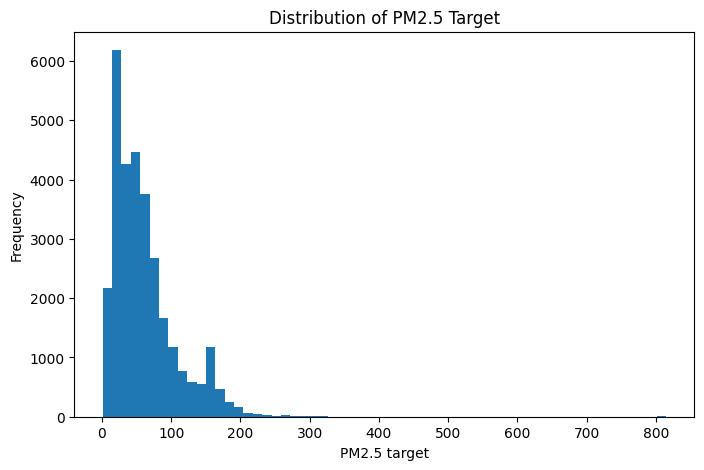

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(train["target"], bins=60)
plt.xlabel("PM2.5 target")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Target")
plt.show()

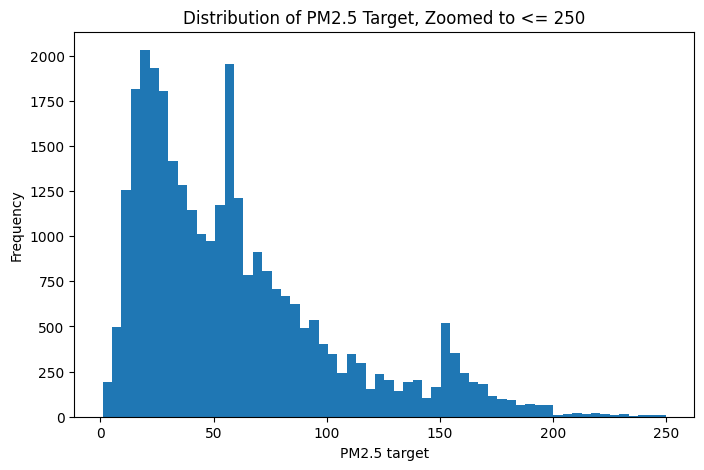

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(train.loc[train["target"] <= 250, "target"], bins=60)
plt.xlabel("PM2.5 target")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Target, Zoomed to <= 250")
plt.show()

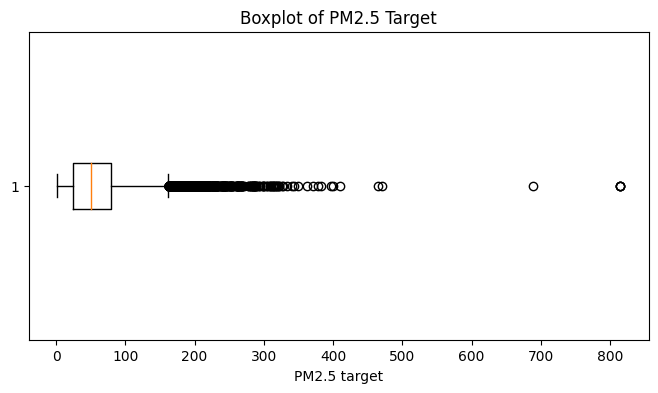

In [20]:
plt.figure(figsize=(8, 4))
plt.boxplot(train["target"], vert=False)
plt.xlabel("PM2.5 target")
plt.title("Boxplot of PM2.5 Target")
plt.show()

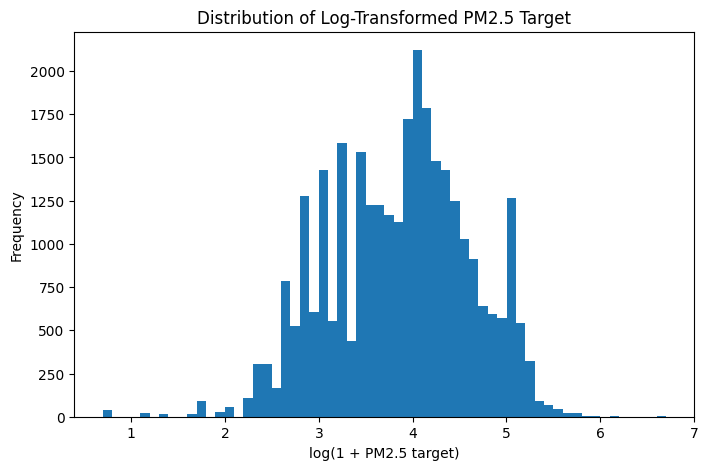

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train["target"]), bins=60)
plt.xlabel("log(1 + PM2.5 target)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed PM2.5 Target")
plt.show()

The target variable contains 30,557 observations. The mean PM2.5 value is approximately 61.15, while the median is 50.00. Since the mean is higher than the median, the target distribution is right-skewed.

The quantile analysis shows that 95% of the observations are below 158 and 99% are below 198. However, the maximum value is 815, which is far above the 99th percentile. This indicates that the dataset contains a small number of extreme pollution events.

This is important for modeling because the evaluation metric is RMSE. RMSE penalizes large prediction errors strongly, so underpredicting rare high-pollution events can significantly worsen the model score.

For the first baseline model, the original target will be used. Later, a log-transformed target using `log(1 + target)` can be tested to check whether it improves the model performance on this right-skewed distribution.


#### Convert date column

In [22]:
# Convert Date column to datetime format
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Train date range:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest date range:")
print(test["Date"].min(), "to", test["Date"].max())

Train date range:
2020-01-02 00:00:00 to 2020-04-04 00:00:00

Test date range:
2020-01-02 00:00:00 to 2020-04-04 00:00:00


#### PM2.5 Over Time

In [23]:
# Check number of unique dates
print("Number of unique train dates:", train["Date"].nunique())
print("Number of unique test dates:", test["Date"].nunique())

Number of unique train dates: 94
Number of unique test dates: 94


In [24]:
# Aggregate PM2.5 target by date
daily_stats = train.groupby("Date")["target"].agg(
    ["mean", "median", "std", "min", "max", "count"]
)

daily_stats.head()

,mean,median,std,min,max,count
Date,,,,,,
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324
2020-01-03,73.618043,59.0,54.179601,3.0,311.0,327
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329
2020-01-05,64.680060,46.0,63.710470,2.0,689.0,331
2020-01-06,63.621713,54.0,47.568742,4.0,252.0,327


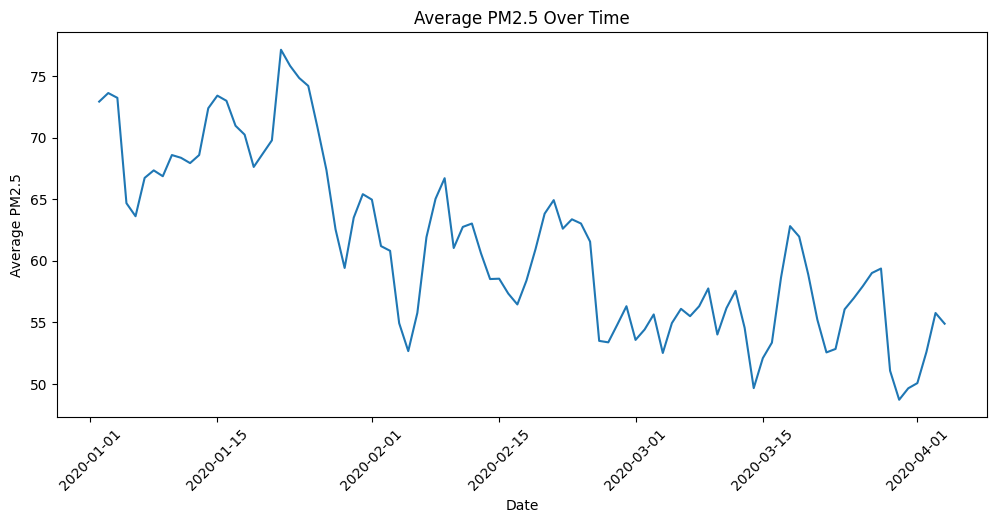

In [25]:
# Average PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["mean"])
plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Over Time")
plt.xticks(rotation=45)
plt.show()

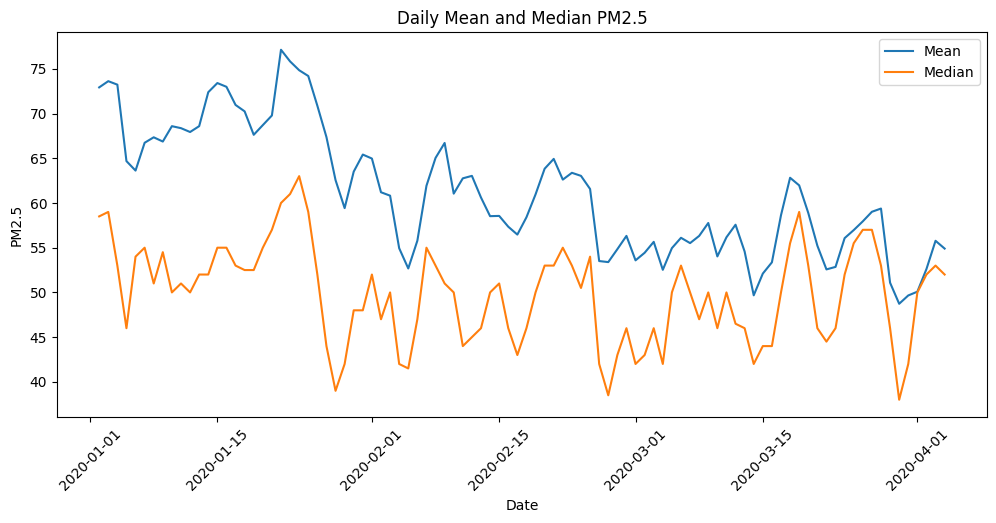

In [26]:
# Mean and median PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["mean"], label="Mean")
plt.plot(daily_stats.index, daily_stats["median"], label="Median")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("Daily Mean and Median PM2.5")
plt.xticks(rotation=45)
plt.legend()
plt.show()

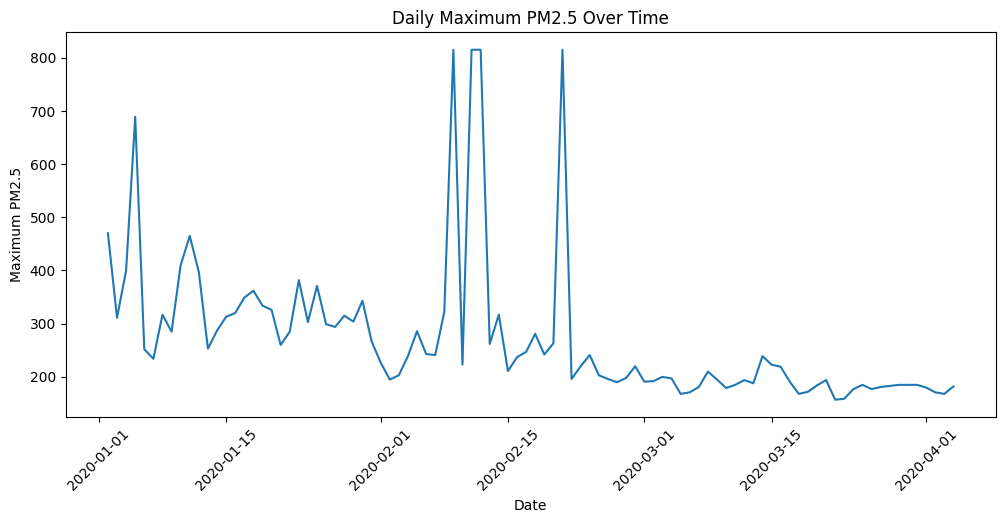

In [27]:
# Daily maximum PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["max"])
plt.xlabel("Date")
plt.ylabel("Maximum PM2.5")
plt.title("Daily Maximum PM2.5 Over Time")
plt.xticks(rotation=45)
plt.show()

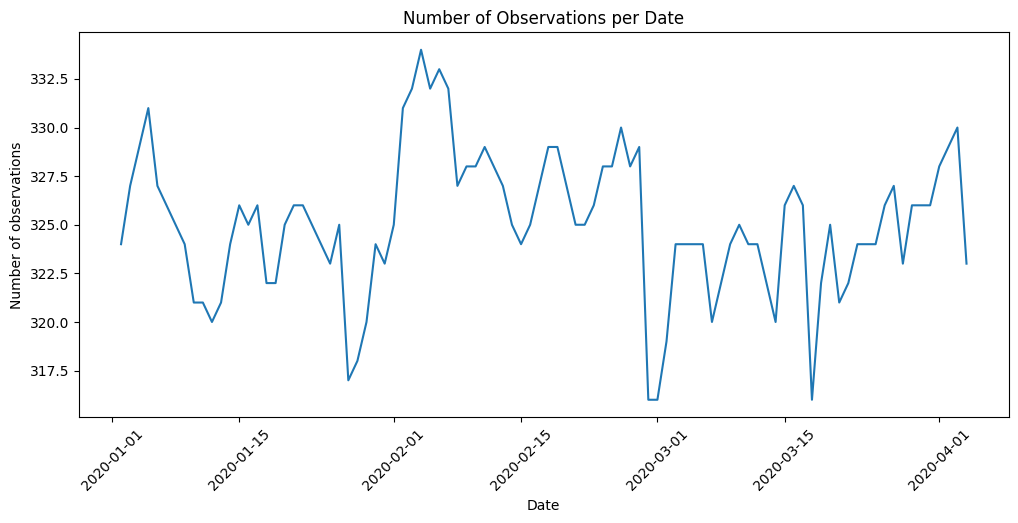

In [28]:
# Number of observations per date
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["count"])
plt.xlabel("Date")
plt.ylabel("Number of observations")
plt.title("Number of Observations per Date")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Top 10 days by average PM2.5
daily_stats.sort_values("mean", ascending=False).head(10)

,mean,median,std,min,max,count
Date,,,,,,
2020-01-22,77.130368,60.0,52.033805,5.0,285.0,326
2020-01-23,75.826462,61.0,54.966476,4.0,382.0,325
2020-01-24,74.839506,63.0,51.319855,5.0,303.0,324
2020-01-25,74.196285,59.0,56.577883,5.0,371.0,323
2020-01-03,73.618043,59.0,54.179601,3.0,311.0,327
2020-01-15,73.407669,55.0,57.151826,3.0,313.0,326
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329
2020-01-16,72.988308,55.0,58.666566,3.0,320.0,325
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324


In [30]:
# Top 10 days by maximum PM2.5
daily_stats.sort_values("max", ascending=False).head(10)

,mean,median,std,min,max,count
Date,,,,,,
2020-02-12,63.030488,45.0,63.141598,1.0,815.0,328
2020-02-21,64.929231,53.0,59.829526,1.0,815.0,325
2020-02-09,66.708537,51.0,64.852613,2.0,815.0,328
2020-02-11,62.754407,44.0,62.542425,1.0,815.0,329
2020-01-05,64.680060,46.0,63.710470,2.0,689.0,331
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324
2020-01-11,68.363863,51.0,58.981736,2.0,465.0,321
2020-01-10,68.587227,50.0,58.635675,1.0,410.0,321
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329


The time-based analysis shows that average PM2.5 varies noticeably over the observed period. The daily mean is generally higher in January and decreases toward March and early April. This indicates that the `Date` column contains useful temporal information for the prediction task.

The daily mean and median curves show that the mean is often higher than the median. This is consistent with the right-skewed target distribution observed earlier and suggests that some high-pollution observations pull the daily mean upward.

The daily maximum plot reveals several extreme PM2.5 values, especially in February, where the maximum reaches 815 on multiple days. However, the daily mean on these days is not the highest in the dataset. This suggests that these extreme values are likely local events at specific locations rather than city-wide or global pollution peaks across all locations.

The number of observations per date is relatively stable, mostly between about 316 and 334 observations. Therefore, the observed temporal variation is unlikely to be caused only by changes in data coverage.

For modeling, the raw `Date` column will be transformed into numerical time features such as `month`, `dayofweek`, `dayofyear`, `weekofyear`, and cyclic seasonal features.


#### PM2.5 by location


In [31]:
place_stats = train.groupby("Place_ID")["target"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).sort_values("mean", ascending=False)

place_stats.head(10)

,mean,median,std,min,max,count
Place_ID,,,,,,
THZR2TS,200.691489,192.5,44.622919,107.0,343.0,94
JABMGKI,166.989362,170.0,52.471087,55.0,313.0,94
EE8C6RP,158.063830,163.5,32.880628,82.0,257.0,94
WMD80ZE,157.212766,154.0,58.423900,50.0,382.0,94
IM6VR3X,154.542553,165.5,80.323093,30.0,400.0,94
RWKDYP8,151.978723,154.0,62.522594,30.0,309.0,94
KXX7F64,151.531915,155.5,70.514500,34.0,327.0,94
NHB348L,150.521277,159.5,31.419030,59.0,220.0,94
H6JSAYZ,149.180851,160.5,48.716640,46.0,238.0,94


In [32]:
place_stats.tail(10)

,mean,median,std,min,max,count
Place_ID,,,,,,
LKE9VQB,17.317073,15.0,8.635505,6.0,43.0,41
0GBXTHY,16.329787,14.0,7.416037,7.0,41.0,94
C146N8V,16.223404,15.0,7.068261,4.0,41.0,94
1Z0FIHB,16.095745,13.0,8.890093,5.0,50.0,94
FH6B9N5,15.536170,14.9,3.008299,11.4,25.6,94
7DRFQCK,15.119048,14.0,10.074906,5.0,87.0,84
RFQQX9G,14.957447,13.0,7.621299,7.0,43.0,94
1ZBVIMD,12.241758,12.0,4.196138,5.0,22.0,91
SI12552,11.709677,9.0,13.636253,5.0,119.0,93


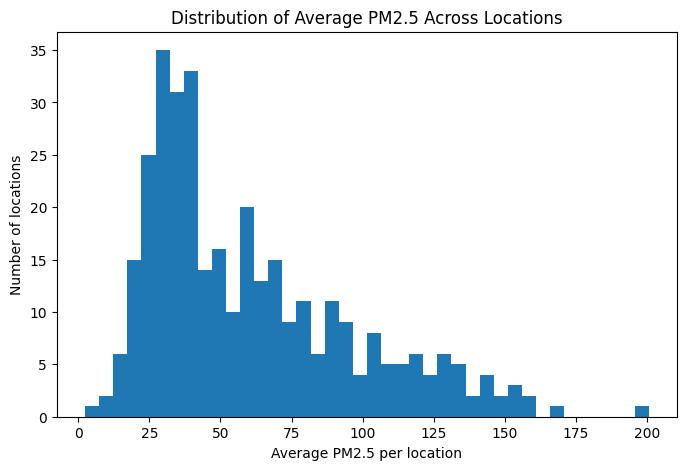

In [33]:
# Distribution of average PM2.5 by location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["mean"], bins=40)
plt.xlabel("Average PM2.5 per location")
plt.ylabel("Number of locations")
plt.title("Distribution of Average PM2.5 Across Locations")
plt.show()

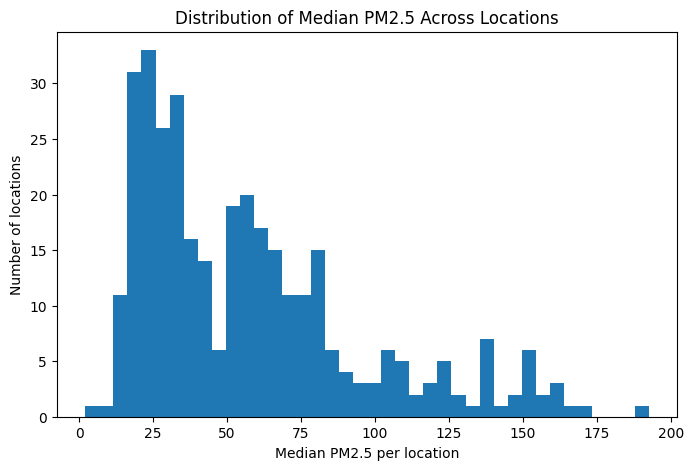

In [34]:
# Distribution of median PM2.5 by location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["median"], bins=40)
plt.xlabel("Median PM2.5 per location")
plt.ylabel("Number of locations")
plt.title("Distribution of Median PM2.5 Across Locations")
plt.show()

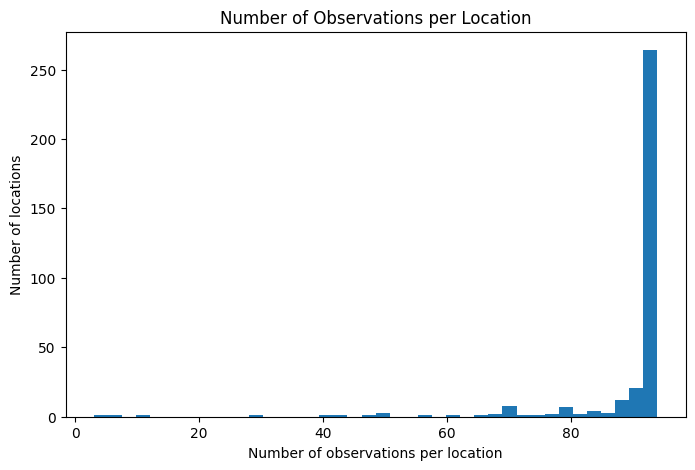

In [35]:
# Number of observations per location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["count"], bins=40)
plt.xlabel("Number of observations per location")
plt.ylabel("Number of locations")
plt.title("Number of Observations per Location")
plt.show()

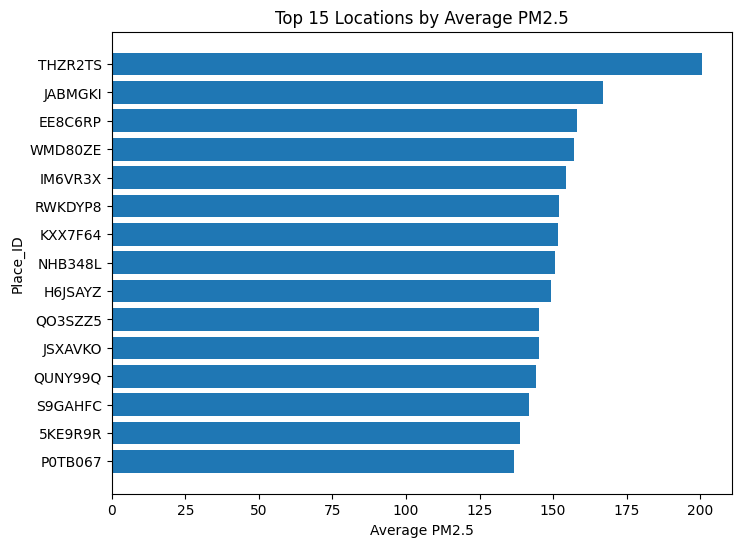

In [36]:
# Top 15 most polluted locations
top_locations = place_stats.head(15).sort_values("mean")

plt.figure(figsize=(8, 6))
plt.barh(top_locations.index, top_locations["mean"])
plt.xlabel("Average PM2.5")
plt.ylabel("Place_ID")
plt.title("Top 15 Locations by Average PM2.5")
plt.show()

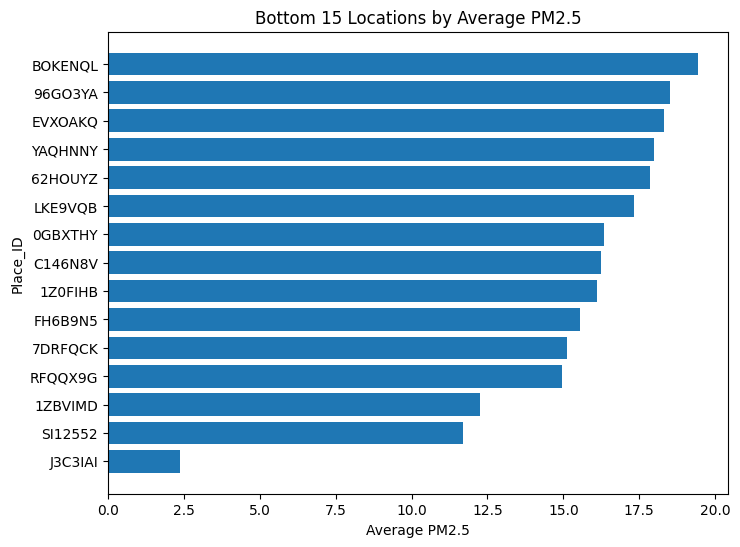

In [37]:
# Bottom 15 least polluted locations
bottom_locations = place_stats.tail(15).sort_values("mean")

plt.figure(figsize=(8, 6))
plt.barh(bottom_locations.index, bottom_locations["mean"])
plt.xlabel("Average PM2.5")
plt.ylabel("Place_ID")
plt.title("Bottom 15 Locations by Average PM2.5")
plt.show()

In [38]:
# Train/test location overlap
train_places = set(train["Place_ID"].unique())
test_places = set(test["Place_ID"].unique())

overlap_places = train_places.intersection(test_places)

print("Number of train locations:", len(train_places))
print("Number of test locations:", len(test_places))
print("Number of overlapping locations:", len(overlap_places))

Number of train locations: 340
Number of test locations: 179
Number of overlapping locations: 0


In [39]:
# Average observations per location
place_stats["count"].describe()

count    340.000000
mean      89.873529
std       11.976324
min        3.000000
25%       92.000000
50%       94.000000
75%       94.000000
max       94.000000
Name: count, dtype: float64

The location-based analysis shows strong spatial variation in PM2.5 levels. Some locations have much higher average PM2.5 concentrations than others, while several locations have consistently low pollution levels. This confirms that air pollution is strongly location-dependent, likely due to differences in traffic, industrial activity, dust, burning sources, local weather, and other environmental conditions.

The distribution of average and median PM2.5 across locations is right-skewed. Most locations have moderate average PM2.5 levels, while a smaller number of locations show very high average pollution. This indicates that some locations are persistent pollution hotspots.

The number of observations per location is mostly high, with many locations having observations for most dates in the dataset. This supports a reliable location-level comparison, although a few locations have fewer observations.

Importantly, the train and test sets have no overlapping `Place_ID`s. The training data contains 340 unique locations, the test data contains 179 unique locations, and the number of overlapping locations is 0. Therefore, raw `Place_ID` should not be used as a direct model feature because the model would learn location-specific patterns that cannot transfer to unseen test locations.

However, `Place_ID` is still very useful for validation. We will use `GroupKFold` with `Place_ID` as the grouping variable to ensure that all observations from the same location stay in the same fold. This gives a more realistic estimate of model performance on unseen locations.


#### Feature relationships with PM2.5

In [40]:
# Create wind speed
train["wind_speed"] = np.sqrt(
    train["u_component_of_wind_10m_above_ground"]**2
    + train["v_component_of_wind_10m_above_ground"]**2
)

test["wind_speed"] = np.sqrt(
    test["u_component_of_wind_10m_above_ground"]**2
    + test["v_component_of_wind_10m_above_ground"]**2
)

In [41]:
# Select key domain features
key_features = [
    "target",
    "precipitable_water_entire_atmosphere",
    "relative_humidity_2m_above_ground",
    "specific_humidity_2m_above_ground",
    "temperature_2m_above_ground",
    "wind_speed",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "L3_NO2_NO2_column_number_density",
    "L3_NO2_tropospheric_NO2_column_number_density",
    "L3_O3_O3_column_number_density",
    "L3_CO_CO_column_number_density",
    "L3_HCHO_tropospheric_HCHO_column_number_density",
    "L3_AER_AI_absorbing_aerosol_index",
    "L3_SO2_SO2_column_number_density",
]

existing_key_features = [col for col in key_features if col in train.columns]

corr_with_target = (
    train[existing_key_features]
    .corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

corr_with_target

target                                             1.000000
L3_CO_CO_column_number_density                     0.375737
L3_HCHO_tropospheric_HCHO_column_number_density    0.347125
L3_NO2_NO2_column_number_density                   0.306772
L3_NO2_tropospheric_NO2_column_number_density      0.295380
L3_AER_AI_absorbing_aerosol_index                  0.070795
L3_SO2_SO2_column_number_density                   0.045052
precipitable_water_entire_atmosphere              -0.031329
specific_humidity_2m_above_ground                 -0.035670
temperature_2m_above_ground                       -0.038818
v_component_of_wind_10m_above_ground              -0.055100
relative_humidity_2m_above_ground                 -0.084835
L3_O3_O3_column_number_density                    -0.088099
u_component_of_wind_10m_above_ground              -0.148202
wind_speed                                        -0.341750
Name: target, dtype: float64

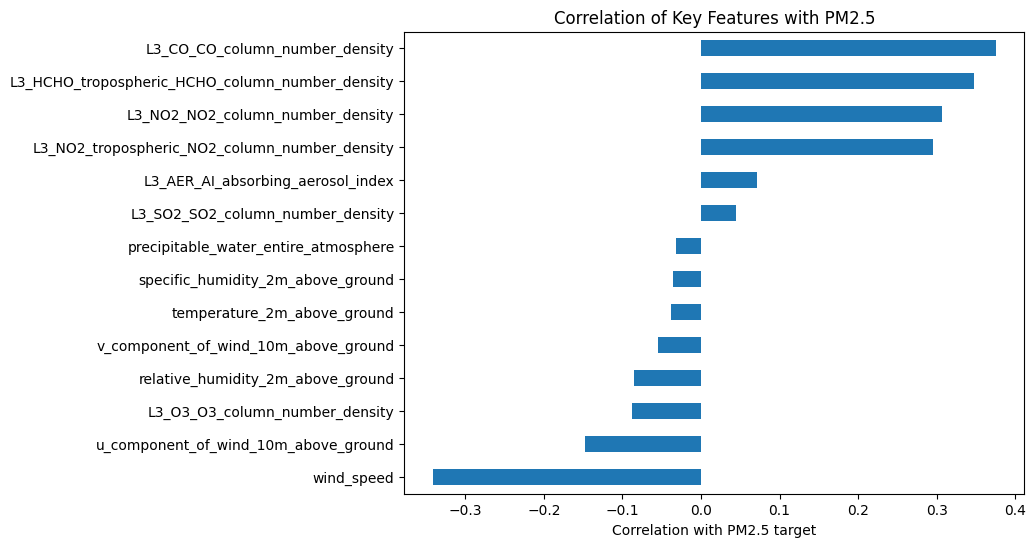

In [42]:
# Plot correlations
plt.figure(figsize=(8, 6))
corr_with_target.drop("target").sort_values().plot(kind="barh")
plt.xlabel("Correlation with PM2.5 target")
plt.title("Correlation of Key Features with PM2.5")
plt.show()

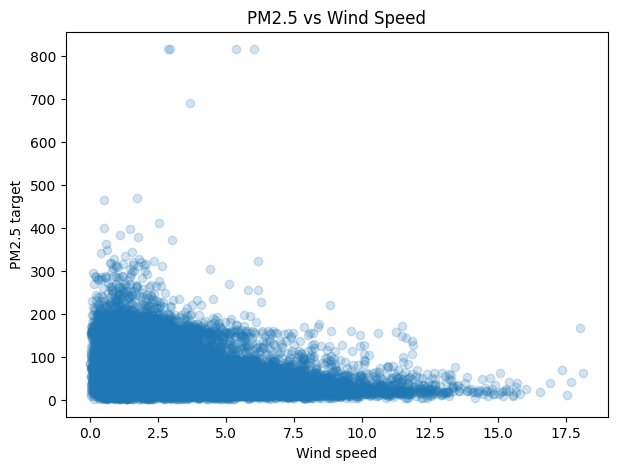

In [43]:
# Scatter: PM2.5 vs wind speed
plt.figure(figsize=(7, 5))
plt.scatter(train["wind_speed"], train["target"], alpha=0.2)
plt.xlabel("Wind speed")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Wind Speed")
plt.show()

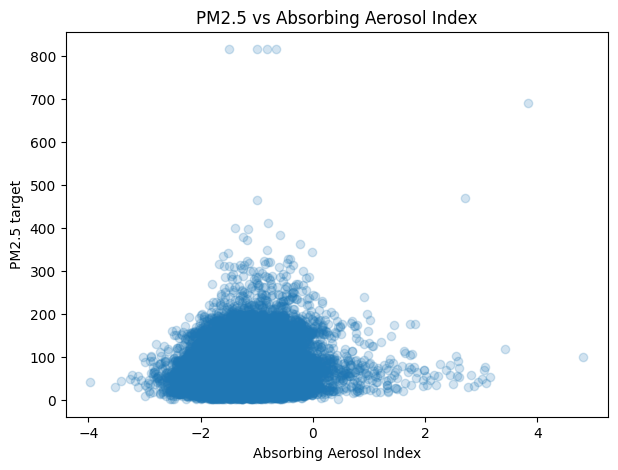

In [44]:
# Scatter: PM2.5 vs aerosol index
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_AER_AI_absorbing_aerosol_index"],
    train["target"],
    alpha=0.2
)
plt.xlabel("Absorbing Aerosol Index")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Absorbing Aerosol Index")
plt.show()

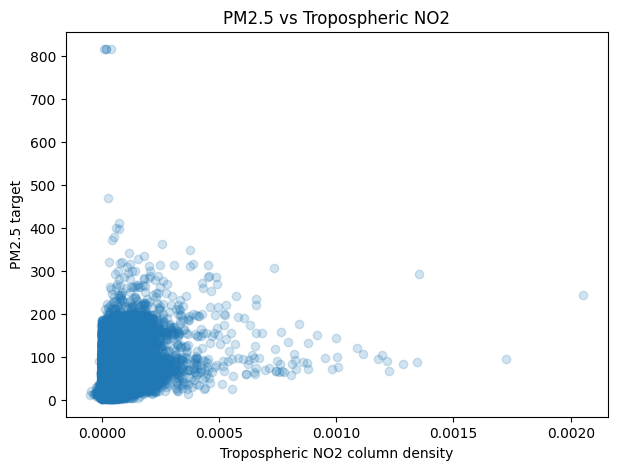

In [45]:
# Scatter: PM2.5 vs NO2 tropospheric column
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_NO2_tropospheric_NO2_column_number_density"],
    train["target"],
    alpha=0.2
)
plt.xlabel("Tropospheric NO2 column density")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Tropospheric NO2")
plt.show()

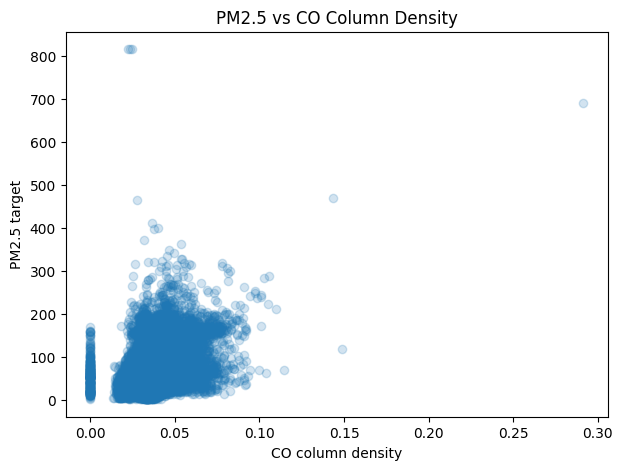

In [46]:
# Scatter: PM2.5 vs CO column
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_CO_CO_column_number_density"],
    train["target"],
    alpha=0.2
)
plt.xlabel("CO column density")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs CO Column Density")
plt.show()

In [47]:
corr_with_target

target                                             1.000000
L3_CO_CO_column_number_density                     0.375737
L3_HCHO_tropospheric_HCHO_column_number_density    0.347125
L3_NO2_NO2_column_number_density                   0.306772
L3_NO2_tropospheric_NO2_column_number_density      0.295380
L3_AER_AI_absorbing_aerosol_index                  0.070795
L3_SO2_SO2_column_number_density                   0.045052
precipitable_water_entire_atmosphere              -0.031329
specific_humidity_2m_above_ground                 -0.035670
temperature_2m_above_ground                       -0.038818
v_component_of_wind_10m_above_ground              -0.055100
relative_humidity_2m_above_ground                 -0.084835
L3_O3_O3_column_number_density                    -0.088099
u_component_of_wind_10m_above_ground              -0.148202
wind_speed                                        -0.341750
Name: target, dtype: float64

The correlation analysis shows that several satellite pollutant features are positively correlated with PM2.5. The strongest positive correlations are observed for CO column density, tropospheric HCHO column density, and NO₂ column density. This is consistent with the domain understanding that CO, HCHO, and NO₂ are related to combustion, traffic, fires, and atmospheric chemical processes that can contribute to PM2.5 pollution.

Wind speed shows the strongest negative correlation with PM2.5. This is physically reasonable because stronger wind can disperse pollutants and reduce local PM2.5 accumulation. However, the relationship may still be complex because wind can also transport dust or smoke from other regions.

Other features, such as ozone, humidity, temperature, SO₂, and aerosol index, show weaker linear correlations. This does not mean they are useless. Correlation only captures linear relationships, while tree-based models can learn nonlinear effects and interactions between variables. Therefore, the correlation analysis is used for understanding the data, but not as the only criterion for feature selection.

## Feature engineering

In [48]:
# Feature engineering functions
def add_date_features(df):
    """Create date-based features from the Date column."""
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Cyclic encoding for yearly/seasonal pattern
    df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    return df


def add_wind_features(df):
    """Create wind speed and wind direction features."""
    df = df.copy()

    u = df["u_component_of_wind_10m_above_ground"]
    v = df["v_component_of_wind_10m_above_ground"]

    df["wind_speed"] = np.sqrt(u**2 + v**2)
    df["wind_direction"] = np.arctan2(v, u)

    # Cyclic encoding for wind direction
    df["wind_dir_sin"] = np.sin(df["wind_direction"])
    df["wind_dir_cos"] = np.cos(df["wind_direction"])

    return df

In [49]:
# Apply feature engineering
train_fe = add_date_features(train)
train_fe = add_wind_features(train_fe)

test_fe = add_date_features(test)
test_fe = add_wind_features(test_fe)

print("Train shape after feature engineering:", train_fe.shape)
print("Test shape after feature engineering:", test_fe.shape)

Train shape after feature engineering: (30557, 94)
Test shape after feature engineering: (16136, 89)


## Feature selection for the first modeling dataset

In [50]:
# Feature groups
weather_features = [
    "precipitable_water_entire_atmosphere",
    "relative_humidity_2m_above_ground",
    "specific_humidity_2m_above_ground",
    "temperature_2m_above_ground",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "wind_speed",
    "wind_dir_sin",
    "wind_dir_cos",
]

date_features = [
    "month",
    "day",
    "dayofweek",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "dayofyear_sin",
    "dayofyear_cos",
]

pollutant_features = [
    "L3_NO2_NO2_column_number_density",
    "L3_NO2_tropospheric_NO2_column_number_density",
    "L3_NO2_absorbing_aerosol_index",

    "L3_O3_O3_column_number_density",

    "L3_CO_CO_column_number_density",
    "L3_CO_H2O_column_number_density",

    "L3_HCHO_tropospheric_HCHO_column_number_density",

    "L3_AER_AI_absorbing_aerosol_index",

    "L3_SO2_SO2_column_number_density",
    "L3_SO2_absorbing_aerosol_index",
]

cloud_features = [
    "L3_NO2_cloud_fraction",
    "L3_O3_cloud_fraction",
    "L3_HCHO_cloud_fraction",
    "L3_SO2_cloud_fraction",

    "L3_CLOUD_cloud_base_height",
    "L3_CLOUD_cloud_base_pressure",
    "L3_CLOUD_cloud_fraction",
    "L3_CLOUD_cloud_optical_depth",
    "L3_CLOUD_cloud_top_height",
    "L3_CLOUD_cloud_top_pressure",
    "L3_CLOUD_surface_albedo",
]

candidate_features = (
    weather_features
    + date_features
    + pollutant_features
    + cloud_features
)

In [51]:
# Keep only existing columns
candidate_features = [col for col in candidate_features if col in train_fe.columns]

print("Number of candidate features:", len(candidate_features))
candidate_features

Number of candidate features: 38


['precipitable_water_entire_atmosphere',
 'relative_humidity_2m_above_ground',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'wind_speed',
 'wind_dir_sin',
 'wind_dir_cos',
 'month',
 'day',
 'dayofweek',
 'dayofyear',
 'weekofyear',
 'is_weekend',
 'dayofyear_sin',
 'dayofyear_cos',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_tropospheric_NO2_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_O3_O3_column_number_density',
 'L3_CO_CO_column_number_density',
 'L3_CO_H2O_column_number_density',
 'L3_HCHO_tropospheric_HCHO_column_number_density',
 'L3_AER_AI_absorbing_aerosol_index',
 'L3_SO2_SO2_column_number_density',
 'L3_SO2_absorbing_aerosol_index',
 'L3_NO2_cloud_fraction',
 'L3_O3_cloud_fraction',
 'L3_HCHO_cloud_fraction',
 'L3_SO2_cloud_fraction',
 'L3_CLOUD_cloud_base_height',
 'L3_CLOUD_cloud_base_pressure',
 'L3_CLOUD_cloud_fraction',
 'L3_CLOUD_cloud_optic

In [52]:
# Remove very high-missing columns (For the first baseline, we remove columns with more than 80% missing values)
missing_ratio = train_fe[candidate_features].isna().mean().sort_values(ascending=False)

high_missing_features = missing_ratio[missing_ratio >= 0.80].index.tolist()
features = missing_ratio[missing_ratio < 0.80].index.tolist()

print("Dropped high-missing features:")
print(high_missing_features)

print("\nNumber of final features:", len(features))
features


Dropped high-missing features:
[]

Number of final features: 38


['L3_NO2_tropospheric_NO2_column_number_density',
 'L3_HCHO_cloud_fraction',
 'L3_HCHO_tropospheric_HCHO_column_number_density',
 'L3_SO2_absorbing_aerosol_index',
 'L3_SO2_cloud_fraction',
 'L3_SO2_SO2_column_number_density',
 'L3_CO_H2O_column_number_density',
 'L3_CO_CO_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_cloud_fraction',
 'L3_CLOUD_cloud_top_pressure',
 'L3_CLOUD_cloud_top_height',
 'L3_CLOUD_cloud_optical_depth',
 'L3_CLOUD_cloud_base_pressure',
 'L3_CLOUD_cloud_base_height',
 'L3_CLOUD_surface_albedo',
 'L3_CLOUD_cloud_fraction',
 'L3_O3_O3_column_number_density',
 'L3_O3_cloud_fraction',
 'L3_AER_AI_absorbing_aerosol_index',
 'dayofyear_cos',
 'wind_dir_cos',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'wind_speed',
 'wind_dir_sin',
 'month',
 'dayofyear_sin',
 'day',
 'dayofweek',
 'dayofyear',
 'weekof

In [53]:
# Define X, y, groups
X = train_fe[features]
y = train_fe["target"]
groups = train_fe["Place_ID"]

X_test = test_fe[features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (30557, 38)
y shape: (30557,)
X_test shape: (16136, 38)


In [54]:
# Check final missing values
final_missing = X.isna().mean().sort_values(ascending=False)

final_missing.head(20)

L3_NO2_tropospheric_NO2_column_number_density      0.283699
L3_HCHO_cloud_fraction                             0.242989
L3_HCHO_tropospheric_HCHO_column_number_density    0.242989
L3_SO2_absorbing_aerosol_index                     0.239160
L3_SO2_cloud_fraction                              0.236836
L3_SO2_SO2_column_number_density                   0.236836
L3_CO_H2O_column_number_density                    0.177472
L3_CO_CO_column_number_density                     0.177472
L3_NO2_cloud_fraction                              0.071637
L3_NO2_NO2_column_number_density                   0.071637
L3_NO2_absorbing_aerosol_index                     0.071637
L3_CLOUD_cloud_top_pressure                        0.049809
L3_CLOUD_cloud_top_height                          0.049809
L3_CLOUD_cloud_optical_depth                       0.049809
L3_CLOUD_cloud_base_pressure                       0.049809
L3_CLOUD_cloud_base_height                         0.049809
L3_CLOUD_surface_albedo                 

In [55]:
print("Number of final features:", len(features))
final_missing.head(20)


Number of final features: 38


L3_NO2_tropospheric_NO2_column_number_density      0.283699
L3_HCHO_cloud_fraction                             0.242989
L3_HCHO_tropospheric_HCHO_column_number_density    0.242989
L3_SO2_absorbing_aerosol_index                     0.239160
L3_SO2_cloud_fraction                              0.236836
L3_SO2_SO2_column_number_density                   0.236836
L3_CO_H2O_column_number_density                    0.177472
L3_CO_CO_column_number_density                     0.177472
L3_NO2_cloud_fraction                              0.071637
L3_NO2_NO2_column_number_density                   0.071637
L3_NO2_absorbing_aerosol_index                     0.071637
L3_CLOUD_cloud_top_pressure                        0.049809
L3_CLOUD_cloud_top_height                          0.049809
L3_CLOUD_cloud_optical_depth                       0.049809
L3_CLOUD_cloud_base_pressure                       0.049809
L3_CLOUD_cloud_base_height                         0.049809
L3_CLOUD_surface_albedo                 

After feature engineering and initial feature selection, the first modeling dataset contains 38 features. These include weather variables, engineered wind features, date-derived features, satellite pollutant features, aerosol indicators, and cloud-context features.

Some satellite features still contain missing values. The highest missingness is observed for the tropospheric NO₂ column density, HCHO-related features, and SO₂-related features. However, the missingness is below the 80% threshold used for feature removal. Therefore, these features are kept in the first modeling dataset.

Missing values will be handled using median imputation inside the preprocessing pipeline. Median imputation is chosen because it is simple, robust to outliers, and suitable for numerical tabular features.

## Missing value handling strategy

#### Define RMSE function

In [56]:
def rmse(y_true, y_pred):
    """Calculate root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

#### Define X, y, and groups

In [57]:
X = train_fe[features]
y = train_fe["target"]
groups = train_fe["Place_ID"]

X_test = test_fe[features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (30557, 38)
y shape: (30557,)
X_test shape: (16136, 38)


#### Preprocessing pipelines

In [58]:
numeric_features = features

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features,
        )
    ]
)

In [59]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ]
)

In [60]:
def cross_validate_model(model, X, y, groups, n_splits=5):
    """
    Evaluate a model using GroupKFold cross-validation.

    GroupKFold ensures that all rows from the same Place_ID
    stay together in either training or validation.
    """
    cv = GroupKFold(n_splits=n_splits)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        fold_rmse = rmse(y_val, preds)
        scores.append(fold_rmse)

        print(f"Fold {fold}: RMSE = {fold_rmse:.4f}")

    print("-" * 40)
    print(f"Mean RMSE: {np.mean(scores):.4f}")
    print(f"Std RMSE:  {np.std(scores):.4f}")

    return scores

## Define baseline models

#### Model pipelines

In [61]:
dummy_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

ridge_pipe = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

hgb_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

Four models are evaluated using GroupKFold cross-validation with `Place_ID` as the grouping variable.

The models are:

1. Dummy Regressor — predicts the mean target value and serves as a minimum baseline.
2. Ridge Regression — a regularized linear model.
3. Random Forest Regressor — a nonlinear ensemble model based on bagging.
4. HistGradientBoosting Regressor — a gradient boosting model for tabular data.

GroupKFold is used because the test set contains locations that are not present in the training set. This validation strategy estimates how well the model generalizes to unseen locations.

#### Run model comparison

In [62]:
models = {
    "Dummy Mean": dummy_pipe,
    "Ridge Regression": ridge_pipe,
    "Random Forest": rf_pipe,
    "HistGradientBoosting": hgb_pipe,
}

results = []

for name, model in models.items():
    print(f"\n{name}")
    print("=" * len(name))

    scores = cross_validate_model(
        model=model,
        X=X,
        y=y,
        groups=groups,
        n_splits=5,
    )

    results.append(
        {
            "model": name,
            "mean_rmse": np.mean(scores),
            "std_rmse": np.std(scores),
        }
    )

results_df = pd.DataFrame(results).sort_values("mean_rmse")
results_df


Dummy Mean
Fold 1: RMSE = 51.5290
Fold 2: RMSE = 46.9687
Fold 3: RMSE = 42.1294
Fold 4: RMSE = 49.3347
Fold 5: RMSE = 44.1746
----------------------------------------
Mean RMSE: 46.8273
Std RMSE:  3.3917

Ridge Regression
Fold 1: RMSE = 41.9313
Fold 2: RMSE = 40.0504
Fold 3: RMSE = 33.7924
Fold 4: RMSE = 41.7987
Fold 5: RMSE = 35.2138
----------------------------------------
Mean RMSE: 38.5573
Std RMSE:  3.4060

Random Forest
Fold 1: RMSE = 36.7709
Fold 2: RMSE = 35.2448
Fold 3: RMSE = 29.6987
Fold 4: RMSE = 39.1003
Fold 5: RMSE = 31.9292
----------------------------------------
Mean RMSE: 34.5488
Std RMSE:  3.3622

HistGradientBoosting
Fold 1: RMSE = 35.9791
Fold 2: RMSE = 34.9737
Fold 3: RMSE = 29.9996
Fold 4: RMSE = 39.0103
Fold 5: RMSE = 31.5571
----------------------------------------
Mean RMSE: 34.3040
Std RMSE:  3.2086


,model,mean_rmse,std_rmse
3,HistGradientBoosting,34.303975,3.208635
2,Random Forest,34.548791,3.362230
1,Ridge Regression,38.557315,3.405995
0,Dummy Mean,46.827269,3.391746


#### Plot model comparison

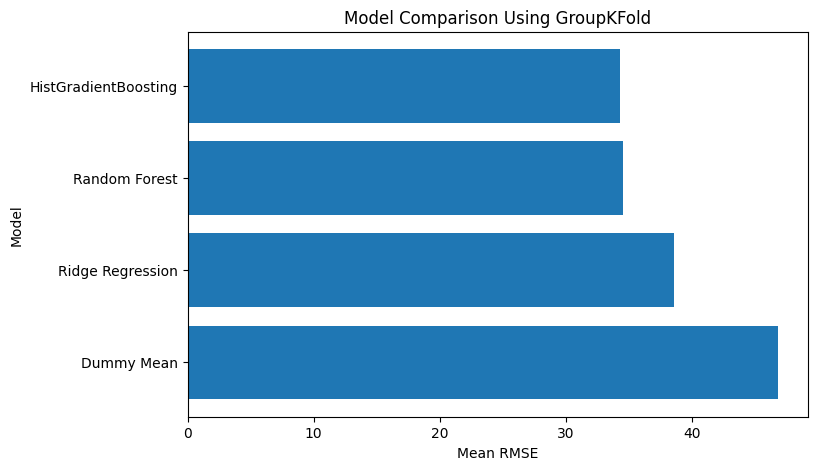

In [63]:
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Model Comparison Using GroupKFold")
plt.gca().invert_yaxis()
plt.show()

The baseline model comparison shows that all machine-learning models perform better than the dummy mean predictor. The Dummy Regressor achieves a mean RMSE of 46.83, which represents the performance of simply predicting the average PM2.5 value for every observation.

Ridge Regression improves the RMSE to 38.56, showing that the selected features contain useful predictive information. However, the nonlinear ensemble models perform substantially better. Random Forest achieves a mean RMSE of 34.55, while HistGradientBoosting achieves the best baseline score with a mean RMSE of 34.30.

This indicates that the relationship between weather, satellite pollutant features, date features, and PM2.5 is likely nonlinear. The best baseline model, HistGradientBoosting, improves the RMSE by approximately 27% compared with the Dummy Regressor.

Since HistGradientBoosting gives the lowest mean RMSE, it is selected as the main candidate for hyperparameter tuning. Random Forest is kept as a strong alternative because its performance is very close.

## Hyperparameter tuning of HistGradientBoosting

In [64]:
from sklearn.model_selection import RandomizedSearchCV

hgb_tuning_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_distributions = {
    "model__learning_rate": [0.02, 0.03, 0.05, 0.07, 0.10],
    "model__max_iter": [200, 300, 500, 700],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

cv = GroupKFold(n_splits=5)

hgb_search = RandomizedSearchCV(
    estimator=hgb_tuning_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

hgb_search.fit(X, y, groups=groups)

print("Best RMSE:", -hgb_search.best_score_)
print("Best parameters:")
hgb_search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RMSE: 33.682450131654726
Best parameters:


{'model__min_samples_leaf': 30,
 'model__max_leaf_nodes': 63,
 'model__max_iter': 700,
 'model__learning_rate': 0.03,
 'model__l2_regularization': 0.01}

In [65]:
print("Best RMSE:", -hgb_search.best_score_)
hgb_search.best_params_

Best RMSE: 33.682450131654726


{'model__min_samples_leaf': 30,
 'model__max_leaf_nodes': 63,
 'model__max_iter': 700,
 'model__learning_rate': 0.03,
 'model__l2_regularization': 0.01}

The best hyperparameters found for the HistGradientBoosting model use a relatively small learning rate of 0.03 together with a high number of boosting iterations, 700. This means the model learns gradually by adding many small corrections.

The maximum number of leaf nodes is 63, which allows each tree to model more complex nonlinear relationships. At the same time, `min_samples_leaf = 30` prevents the trees from creating very small leaves that may overfit individual observations. A small L2 regularization value of 0.01 is also used to improve generalization.

Overall, the tuned model is more flexible than the initial baseline HistGradientBoosting model, but it still includes regularization to reduce overfitting.


#### Comparison with the HistGradientBoosting base-line model

In [66]:
print("Baseline HistGradientBoosting RMSE:", results_df.loc[
    results_df["model"] == "HistGradientBoosting", "mean_rmse"
].values[0])

print("Tuned HistGradientBoosting RMSE:", -hgb_search.best_score_)

Baseline HistGradientBoosting RMSE: 34.30397454467803
Tuned HistGradientBoosting RMSE: 33.682450131654726


In [67]:
baseline_hgb_rmse = results_df.loc[
    results_df["model"] == "HistGradientBoosting", "mean_rmse"
].values[0]

tuned_hgb_rmse = -hgb_search.best_score_

improvement = baseline_hgb_rmse - tuned_hgb_rmse
improvement_percent = improvement / baseline_hgb_rmse * 100

print(f"Improvement in RMSE: {improvement:.4f}")
print(f"Improvement percentage: {improvement_percent:.2f}%")

Improvement in RMSE: 0.6215
Improvement percentage: 1.81%


#### Tuned final HGB pipeline

In [68]:
tuned_hgb_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                min_samples_leaf=30,
                max_leaf_nodes=63,
                max_iter=700,
                learning_rate=0.03,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

Hyperparameter tuning improved the HistGradientBoosting model. The baseline HistGradientBoosting model achieved a mean GroupKFold RMSE of 34.30, while the tuned model achieved a mean RMSE of 33.68.

This corresponds to an improvement of approximately 0.62 RMSE points, or about 1.8%. The improvement is moderate, but meaningful, because the baseline HistGradientBoosting model was already the strongest initial model.

The tuned HistGradientBoosting model is therefore selected as the current best model. It will be used as the main candidate for final training and test-set prediction, unless further experiments such as missingness indicators or log-target transformation improve the validation score.


#### Updated results table

In [69]:
tuned_result = pd.DataFrame(
    [
        {
            "model": "Tuned HistGradientBoosting",
            "mean_rmse": -hgb_search.best_score_,
            "std_rmse": np.nan,
        }
    ]
)

results_with_tuned_df = pd.concat(
    [results_df, tuned_result],
    ignore_index=True
).sort_values("mean_rmse")

results_with_tuned_df

,model,mean_rmse,std_rmse
4,Tuned HistGradientBoosting,33.682450,NaN
0,HistGradientBoosting,34.303975,3.208635
1,Random Forest,34.548791,3.362230
2,Ridge Regression,38.557315,3.405995
3,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

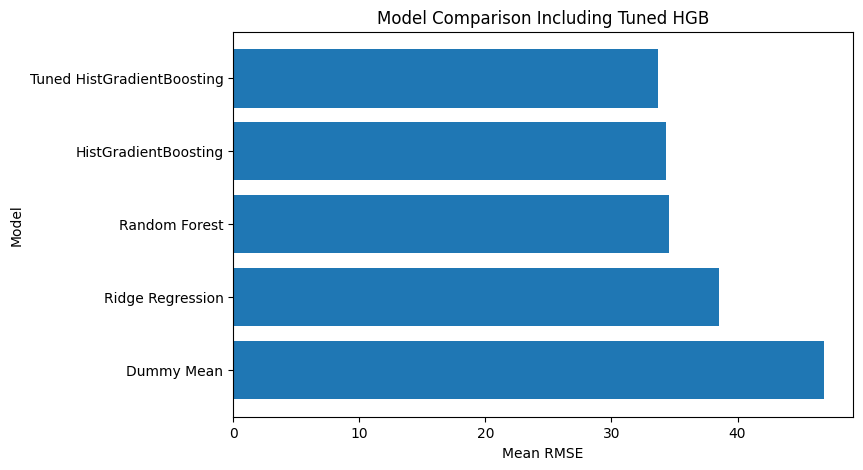

In [70]:
plt.figure(figsize=(8, 5))
plt.barh(results_with_tuned_df["model"], results_with_tuned_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Model Comparison Including Tuned HGB")
plt.gca().invert_yaxis()
plt.show()

## Tests 

#### Missingness indicators

In [72]:
# Use the same tuned HGB parameters
tree_preprocessor_missing = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            ),
            numeric_features,
        )
    ]
)

In [73]:
tuned_hgb_missing_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor_missing),
        (
            "model",
            HistGradientBoostingRegressor(
                min_samples_leaf=30,
                max_leaf_nodes=63,
                max_iter=700,
                learning_rate=0.03,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [74]:
# Evaluate it
print("Tuned HGB with missingness indicators")
print("=" * 43)

hgb_missing_scores = cross_validate_model(
    model=tuned_hgb_missing_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

hgb_missing_mean_rmse = np.mean(hgb_missing_scores)
hgb_missing_std_rmse = np.std(hgb_missing_scores)

print(f"Mean RMSE: {hgb_missing_mean_rmse:.4f}")
print(f"Std RMSE:  {hgb_missing_std_rmse:.4f}")

Tuned HGB with missingness indicators
Fold 1: RMSE = 35.6431
Fold 2: RMSE = 33.8983
Fold 3: RMSE = 29.1740
Fold 4: RMSE = 38.4219
Fold 5: RMSE = 30.8909
----------------------------------------
Mean RMSE: 33.6056
Std RMSE:  3.2998
Mean RMSE: 33.6056
Std RMSE:  3.2998


In [75]:
# Compare
print(f"Current best tuned HGB RMSE:       {tuned_hgb_rmse:.4f}")
print(f"HGB + missing indicators RMSE:     {hgb_missing_mean_rmse:.4f}")

difference = tuned_hgb_rmse - hgb_missing_mean_rmse
difference_percent = difference / tuned_hgb_rmse * 100

print(f"Difference in RMSE: {difference:.4f}")
print(f"Difference percentage: {difference_percent:.2f}%")

Current best tuned HGB RMSE:       33.6825
HGB + missing indicators RMSE:     33.6056
Difference in RMSE: 0.0768
Difference percentage: 0.23%


Adding missingness indicators slightly improved the tuned HistGradientBoosting model. The RMSE decreased from 33.68 to 33.61, corresponding to an improvement of approximately 0.08 RMSE points or 0.23%.

The improvement is small, but it suggests that missing values in the satellite features may contain some useful information. This is plausible because missing satellite measurements can be related to cloud cover, retrieval quality, or atmospheric conditions.

Since this experiment achieved the lowest validation RMSE so far, the pipeline with missingness indicators is kept for the next experiment.

#### Log target

In [76]:
best_hgb_pipe = tuned_hgb_missing_pipe
best_rmse_before_log = hgb_missing_mean_rmse

print("Best pipeline before log target: Tuned HGB + missingness indicators")
print(f"Best RMSE before log target: {best_rmse_before_log:.4f}")

Best pipeline before log target: Tuned HGB + missingness indicators
Best RMSE before log target: 33.6056


In [77]:
from sklearn.compose import TransformedTargetRegressor

log_best_hgb_pipe = TransformedTargetRegressor(
    regressor=best_hgb_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

In [78]:
# Evaluate
print("Tuned HGB + missingness indicators + log target")
print("=" * 52)

log_best_hgb_scores = cross_validate_model(
    model=log_best_hgb_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

log_best_hgb_mean_rmse = np.mean(log_best_hgb_scores)
log_best_hgb_std_rmse = np.std(log_best_hgb_scores)

print(f"Mean RMSE: {log_best_hgb_mean_rmse:.4f}")
print(f"Std RMSE:  {log_best_hgb_std_rmse:.4f}")

Tuned HGB + missingness indicators + log target
Fold 1: RMSE = 38.0462
Fold 2: RMSE = 36.8488
Fold 3: RMSE = 29.8317
Fold 4: RMSE = 39.7263
Fold 5: RMSE = 30.8731
----------------------------------------
Mean RMSE: 35.0652
Std RMSE:  3.9688
Mean RMSE: 35.0652
Std RMSE:  3.9688


A log-transformed target was tested because the PM2.5 target distribution is right-skewed and contains extreme values. The model was trained on `log(1 + target)` and predictions were transformed back to the original PM2.5 scale before calculating RMSE.

The log-target model achieved a mean GroupKFold RMSE of 35.07, which is worse than the tuned HistGradientBoosting model with missingness indicators on the original target, which achieved an RMSE of 33.61.

Therefore, the log-transformed target is not used in the final model. Although log transformation can help with skewed target distributions, it can also reduce the model’s ability to predict extreme high PM2.5 values. Since the evaluation metric is RMSE on the original scale, underpredicting high pollution events can strongly increase the error.

The final selected model is therefore the tuned HistGradientBoosting model with missingness indicators and the original PM2.5 target.


#### Updated results table

In [79]:
log_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Missing Indicators + Log Target",
            "mean_rmse": log_best_hgb_mean_rmse,
            "std_rmse": log_best_hgb_std_rmse,
        }
    ]
)

missing_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Missing Indicators",
            "mean_rmse": hgb_missing_mean_rmse,
            "std_rmse": hgb_missing_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [results_with_tuned_df, missing_result, log_result],
    ignore_index=True
).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
5,Tuned HGB + Missing Indicators,33.605621,3.299777
0,Tuned HistGradientBoosting,33.682450,NaN
1,HistGradientBoosting,34.303975,3.208635
2,Random Forest,34.548791,3.362230
6,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
3,Ridge Regression,38.557315,3.405995
4,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

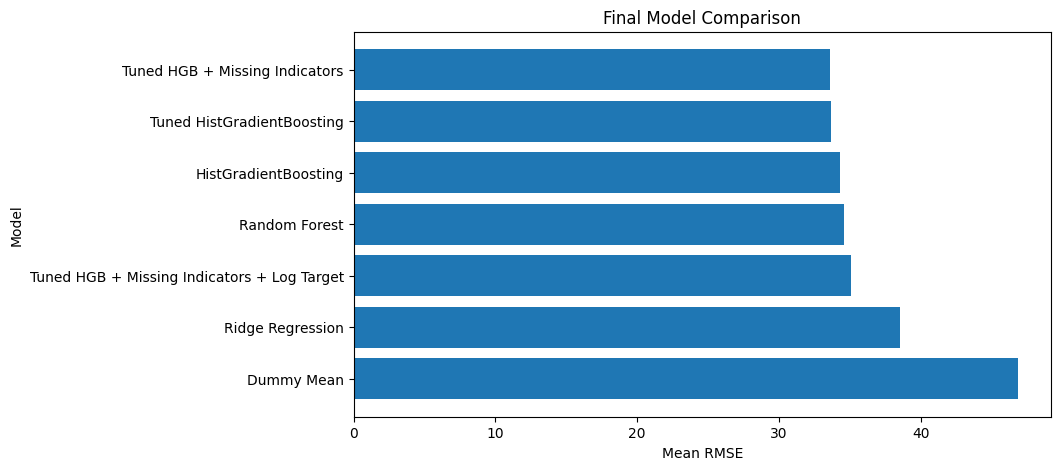

In [80]:
plt.figure(figsize=(9, 5))
plt.barh(final_results_df["model"], final_results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Final Model Comparison")
plt.gca().invert_yaxis()
plt.show()

## Further experiments

#### Try HGB without imputation

In [81]:
hgb_native_missing_pipe = Pipeline(
    steps=[
        (
            "model",
            HistGradientBoostingRegressor(
                min_samples_leaf=30,
                max_leaf_nodes=63,
                max_iter=700,
                learning_rate=0.03,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

native_missing_scores = cross_validate_model(
    model=hgb_native_missing_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

native_missing_mean_rmse = np.mean(native_missing_scores)
native_missing_std_rmse = np.std(native_missing_scores)

print(f"Native-missing HGB RMSE: {native_missing_mean_rmse:.4f}")
print(f"Std RMSE: {native_missing_std_rmse:.4f}")

Fold 1: RMSE = 35.5461
Fold 2: RMSE = 33.9799
Fold 3: RMSE = 28.9915
Fold 4: RMSE = 38.4164
Fold 5: RMSE = 30.6743
----------------------------------------
Mean RMSE: 33.5216
Std RMSE:  3.3733
Native-missing HGB RMSE: 33.5216
Std RMSE: 3.3733


In [82]:
print(f"Median + indicators RMSE: {hgb_missing_mean_rmse:.4f}")
print(f"Native-missing HGB RMSE:  {native_missing_mean_rmse:.4f}")

Median + indicators RMSE: 33.6056
Native-missing HGB RMSE:  33.5216


A further experiment was performed using the native missing-value handling of `HistGradientBoostingRegressor`. Unlike Random Forest or Ridge Regression, this model can handle missing numerical values directly without median imputation.

The native-missing HistGradientBoosting model achieved a mean GroupKFold RMSE of 33.52, compared with 33.61 for the model using median imputation and missingness indicators. This is a small but consistent improvement.

Therefore, the native-missing HistGradientBoosting model becomes the best model so far. This suggests that, for this dataset, allowing the boosting model to learn how to split missing values directly is more effective than replacing missing values with median values.


#### Updated best model

In [83]:
best_model_name = "Tuned HGB with Native Missing Handling"
best_model = hgb_native_missing_pipe
best_rmse = native_missing_mean_rmse

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

Current best model: Tuned HGB with Native Missing Handling
Current best RMSE: 33.5216


#### Updated results table

In [84]:
native_missing_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Native Missing",
            "mean_rmse": native_missing_mean_rmse,
            "std_rmse": native_missing_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, native_missing_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
7,Tuned HGB + Native Missing,33.521645,3.373331
0,Tuned HGB + Missing Indicators,33.605621,3.299777
1,Tuned HistGradientBoosting,33.682450,NaN
2,HistGradientBoosting,34.303975,3.208635
3,Random Forest,34.548791,3.362230
4,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
5,Ridge Regression,38.557315,3.405995
6,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

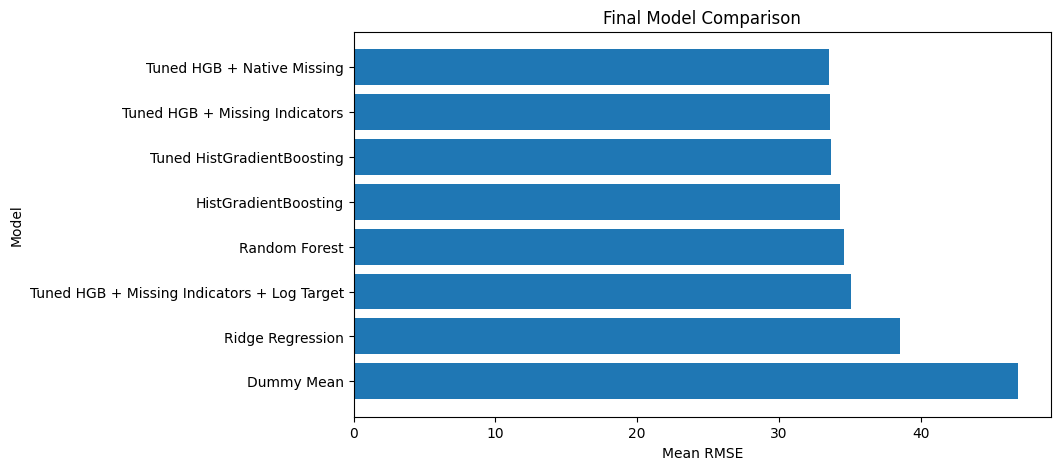

In [85]:
plt.figure(figsize=(9, 5))
plt.barh(final_results_df["model"], final_results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Final Model Comparison")
plt.gca().invert_yaxis()
plt.show()

#### Try ExtraTreesRegressor

In [86]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor_missing),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

extra_trees_scores = cross_validate_model(
    model=extra_trees_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

extra_trees_mean_rmse = np.mean(extra_trees_scores)
extra_trees_std_rmse = np.std(extra_trees_scores)

print(f"ExtraTrees RMSE: {extra_trees_mean_rmse:.4f}")
print(f"Std RMSE: {extra_trees_std_rmse:.4f}")

Fold 1: RMSE = 35.5852
Fold 2: RMSE = 34.4048
Fold 3: RMSE = 29.1107
Fold 4: RMSE = 38.1744
Fold 5: RMSE = 31.1494
----------------------------------------
Mean RMSE: 33.6849
Std RMSE:  3.2136
ExtraTrees RMSE: 33.6849
Std RMSE: 3.2136


The ExtraTreesRegressor achieved a mean GroupKFold RMSE of 33.68. This is better than the Dummy and Ridge baselines, but it does not outperform the tuned HistGradientBoosting model with native missing-value handling, which achieved an RMSE of 33.52.

Therefore, ExtraTrees is not selected as the final standalone model. However, since it is a different ensemble method, it may still be useful later as part of an ensemble average.

#### Updated results table

In [87]:
extra_trees_result = pd.DataFrame(
    [
        {
            "model": "ExtraTrees + Missing Indicators",
            "mean_rmse": extra_trees_mean_rmse,
            "std_rmse": extra_trees_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, extra_trees_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
0,Tuned HGB + Native Missing,33.521645,3.373331
1,Tuned HGB + Missing Indicators,33.605621,3.299777
2,Tuned HistGradientBoosting,33.682450,NaN
8,ExtraTrees + Missing Indicators,33.684896,3.213631
3,HistGradientBoosting,34.303975,3.208635
4,Random Forest,34.548791,3.362230
5,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
6,Ridge Regression,38.557315,3.405995
7,Dummy Mean,46.827269,3.391746


#### Try LightGBM baseline

In [88]:
from lightgbm import LGBMRegressor

lgbm_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                n_estimators=700,
                learning_rate=0.03,
                num_leaves=63,
                min_child_samples=30,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=0.01,
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

lgbm_scores = cross_validate_model(
    model=lgbm_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

lgbm_mean_rmse = np.mean(lgbm_scores)
lgbm_std_rmse = np.std(lgbm_scores)

print(f"LightGBM RMSE: {lgbm_mean_rmse:.4f}")
print(f"Std RMSE:     {lgbm_std_rmse:.4f}")

Fold 1: RMSE = 35.4007
Fold 2: RMSE = 33.7355
Fold 3: RMSE = 28.7817
Fold 4: RMSE = 38.2712
Fold 5: RMSE = 30.5072
----------------------------------------
Mean RMSE: 33.3393
Std RMSE:  3.3918
LightGBM RMSE: 33.3393
Std RMSE:     3.3918


In [89]:
# Compare
print(f"Current best HGB RMSE: {native_missing_mean_rmse:.4f}")
print(f"LightGBM RMSE:         {lgbm_mean_rmse:.4f}")

Current best HGB RMSE: 33.5216
LightGBM RMSE:         33.3393


LightGBM achieved a mean GroupKFold RMSE of 33.34, which is better than the best sklearn HistGradientBoosting model with native missing-value handling. This makes LightGBM the best standalone model so far.

The improvement is moderate but meaningful in the competition context, where small RMSE reductions can matter. Since LightGBM can handle missing values natively and is optimized for tabular data, it is selected as the current best candidate model.

#### Updated best model

In [90]:
best_model_name = "LightGBM"
best_model = lgbm_pipe
best_rmse = lgbm_mean_rmse

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

Current best model: LightGBM
Current best RMSE: 33.3393


#### Updated results table

In [91]:
lgbm_result = pd.DataFrame(
    [
        {
            "model": "LightGBM",
            "mean_rmse": lgbm_mean_rmse,
            "std_rmse": lgbm_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
9,LightGBM,33.339263,3.391806
0,Tuned HGB + Native Missing,33.521645,3.373331
1,Tuned HGB + Missing Indicators,33.605621,3.299777
2,Tuned HistGradientBoosting,33.682450,NaN
3,ExtraTrees + Missing Indicators,33.684896,3.213631
4,HistGradientBoosting,34.303975,3.208635
5,Random Forest,34.548791,3.362230
6,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
7,Ridge Regression,38.557315,3.405995
8,Dummy Mean,46.827269,3.391746


#### Try XGBoost baseline

In [92]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline(
    steps=[
        (
            "model",
            XGBRegressor(
                n_estimators=700,
                learning_rate=0.03,
                max_depth=6,
                min_child_weight=5,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=1.0,
                objective="reg:squarederror",
                eval_metric="rmse",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_scores = cross_validate_model(
    model=xgb_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

xgb_mean_rmse = np.mean(xgb_scores)
xgb_std_rmse = np.std(xgb_scores)

print(f"XGBoost RMSE: {xgb_mean_rmse:.4f}")
print(f"Std RMSE:    {xgb_std_rmse:.4f}")

Fold 1: RMSE = 35.7144
Fold 2: RMSE = 34.0988
Fold 3: RMSE = 29.3715
Fold 4: RMSE = 38.3918
Fold 5: RMSE = 30.9998
----------------------------------------
Mean RMSE: 33.7153
Std RMSE:  3.2328
XGBoost RMSE: 33.7153
Std RMSE:    3.2328


In [93]:
# Compare
print(f"Current best LightGBM RMSE: {lgbm_mean_rmse:.4f}")
print(f"XGBoost RMSE:              {xgb_mean_rmse:.4f}")

Current best LightGBM RMSE: 33.3393
XGBoost RMSE:              33.7153


XGBoost was tested as an additional gradient-boosting model. It achieved a mean GroupKFold RMSE of 33.72. This is better than the original baseline models, but it does not outperform LightGBM, which achieved the best score so far with an RMSE of 33.34.

Therefore, XGBoost is not selected as the final standalone model. LightGBM remains the current best candidate for final prediction and further tuning.

#### Updated best model

In [95]:
# Lock the tuned LightGBM model as the current best model
tuned_lgbm_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                n_estimators=1500,
                learning_rate=0.03,
                num_leaves=95,
                min_child_samples=20,
                subsample=1.0,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=0.1,
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

best_model_name = "Tuned LightGBM"
best_model = tuned_lgbm_pipe
best_rmse = -lgbm_search.best_score_

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

NameError: name 'lgbm_search' is not defined

#### Updated results table

In [98]:
tuned_lgbm_result = pd.DataFrame(
    [
        {
            "model": "Tuned LightGBM",
            "mean_rmse": best_rmse,
            "std_rmse": np.nan,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, tuned_lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
0,LightGBM,33.339263,3.391806
10,Tuned LightGBM,33.339263,NaN
1,Tuned HGB + Native Missing,33.521645,3.373331
2,Tuned HGB + Missing Indicators,33.605621,3.299777
3,Tuned HistGradientBoosting,33.682450,NaN
4,ExtraTrees + Missing Indicators,33.684896,3.213631
5,HistGradientBoosting,34.303975,3.208635
6,Random Forest,34.548791,3.362230
7,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
8,Ridge Regression,38.557315,3.405995


## Tune LightGBM

In [99]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

lgbm_search_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

param_distributions = {
    "model__n_estimators": [500, 700, 900, 1200, 1500],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07],
    "model__num_leaves": [31, 63, 95, 127],
    "model__min_child_samples": [10, 20, 30, 50, 80],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.001, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.0, 0.001, 0.01, 0.1, 1.0],
}

cv = GroupKFold(n_splits=5)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_search_pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

lgbm_search.fit(X, y, groups=groups)

print("Best LightGBM RMSE:", -lgbm_search.best_score_)
print("Best parameters:")
lgbm_search.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best LightGBM RMSE: 33.03923915670861
Best parameters:


{'model__subsample': 1.0,
 'model__reg_lambda': 0.1,
 'model__reg_alpha': 0.01,
 'model__num_leaves': 95,
 'model__n_estimators': 1500,
 'model__min_child_samples': 20,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 0.9}

In [100]:
print("Best LightGBM RMSE:", -lgbm_search.best_score_)
lgbm_search.best_params_

Best LightGBM RMSE: 33.03923915670861


{'model__subsample': 1.0,
 'model__reg_lambda': 0.1,
 'model__reg_alpha': 0.01,
 'model__num_leaves': 95,
 'model__n_estimators': 1500,
 'model__min_child_samples': 20,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 0.9}

LightGBM was tuned using RandomizedSearchCV with GroupKFold validation. The tuned LightGBM model achieved a mean RMSE of 33.04, improving over the initial LightGBM score of 33.34 and the best sklearn HistGradientBoosting score of 33.52.

This makes tuned LightGBM the best standalone model so far. The selected configuration uses a relatively small learning rate of 0.03 together with 1500 estimators, allowing the model to learn gradually. The model also uses 95 leaves per tree, moderate regularization, and 90% feature sampling per tree.

Since the validation strategy uses GroupKFold by `Place_ID`, this score estimates how well the model generalizes to unseen locations.

#### Tuned LightGBM final pipeline

In [101]:
tuned_lgbm_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                n_estimators=1500,
                learning_rate=0.03,
                num_leaves=95,
                min_child_samples=20,
                subsample=1.0,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=0.1,
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

best_model_name = "Tuned LightGBM"
best_model = tuned_lgbm_pipe
best_rmse = -lgbm_search.best_score_

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

Current best model: Tuned LightGBM
Current best RMSE: 33.0392


#### Updated results table

In [102]:
tuned_lgbm_result = pd.DataFrame(
    [
        {
            "model": "Tuned LightGBM",
            "mean_rmse": -lgbm_search.best_score_,
            "std_rmse": np.nan,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, tuned_lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
0,LightGBM,33.339263,3.391806
1,Tuned LightGBM,33.339263,NaN
2,Tuned HGB + Native Missing,33.521645,3.373331
3,Tuned HGB + Missing Indicators,33.605621,3.299777
4,Tuned HistGradientBoosting,33.682450,NaN
5,ExtraTrees + Missing Indicators,33.684896,3.213631
6,HistGradientBoosting,34.303975,3.208635
7,Random Forest,34.548791,3.362230
8,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807
9,Ridge Regression,38.557315,3.405995


## Ensembling

#### Define ensemble models

In [103]:
ensemble_models = {
    "Tuned LightGBM": tuned_lgbm_pipe,
    "Native HGB": hgb_native_missing_pipe,
    "ExtraTrees": extra_trees_pipe,
}

for name, model in ensemble_models.items():
    print(name, "loaded")

Tuned LightGBM loaded
Native HGB loaded
ExtraTrees loaded


#### Create out-of-fold predictions

In [104]:
def get_oof_predictions(models, X, y, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)

    oof_preds = pd.DataFrame(index=X.index)
    fold_ids = pd.Series(index=X.index, dtype=int)

    individual_scores = {name: [] for name in models.keys()}

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        print(f"\nFold {fold}")

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        fold_ids.iloc[val_idx] = fold

        for name, model in models.items():
            model_clone = clone(model)
            model_clone.fit(X_train, y_train)

            preds = model_clone.predict(X_val)
            oof_preds.loc[X_val.index, name] = preds

            score = rmse(y_val, preds)
            individual_scores[name].append(score)

            print(f"{name}: RMSE = {score:.4f}")

    return oof_preds, fold_ids, individual_scores


oof_preds, fold_ids, individual_scores = get_oof_predictions(
    models=ensemble_models,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)


Fold 1
Tuned LightGBM: RMSE = 34.9631
Native HGB: RMSE = 35.5461
ExtraTrees: RMSE = 35.5852

Fold 2
Tuned LightGBM: RMSE = 33.3884
Native HGB: RMSE = 33.9799
ExtraTrees: RMSE = 34.4048

Fold 3
Tuned LightGBM: RMSE = 28.7270
Native HGB: RMSE = 28.9915
ExtraTrees: RMSE = 29.1107

Fold 4
Tuned LightGBM: RMSE = 37.9812
Native HGB: RMSE = 38.4164
ExtraTrees: RMSE = 38.1744

Fold 5
Tuned LightGBM: RMSE = 30.1365
Native HGB: RMSE = 30.6743
ExtraTrees: RMSE = 31.1494


#### Search for the best weights

In [106]:
def evaluate_ensemble_weights(oof_preds, y, fold_ids, weights):
    weights = np.array(weights)
    weights = weights / weights.sum()

    ensemble_pred = np.average(
        oof_preds.values,
        axis=1,
        weights=weights
    )

    fold_scores = []

    for fold in sorted(fold_ids.unique()):
        mask = fold_ids == fold
        fold_score = rmse(y.loc[mask], ensemble_pred[mask])
        fold_scores.append(fold_score)

    return np.mean(fold_scores), np.std(fold_scores), fold_scores


weight_results = []

model_names = list(ensemble_models.keys())

for w_lgbm in np.arange(0.50, 1.01, 0.05):
    for w_hgb in np.arange(0.00, 0.51, 0.05):
        w_extra = 1.0 - w_lgbm - w_hgb

        if w_extra < 0:
            continue

        weights = [w_lgbm, w_hgb, w_extra]

        mean_rmse, std_rmse, fold_scores = evaluate_ensemble_weights(
            oof_preds=oof_preds,
            y=y,
            fold_ids=fold_ids,
            weights=weights,
        )

        weight_results.append(
            {
                "w_lgbm": w_lgbm,
                "w_hgb": w_hgb,
                "w_extra": w_extra,
                "mean_rmse": mean_rmse,
                "std_rmse": std_rmse,
            }
        )

weight_results_df = pd.DataFrame(weight_results).sort_values("mean_rmse")

weight_results_df.head(10)

,w_lgbm,w_hgb,w_extra,mean_rmse,std_rmse
28,0.65,0.00,0.35,32.813660,3.333018
29,0.65,0.05,0.30,32.815525,3.339706
35,0.70,0.00,0.30,32.815917,3.334949
21,0.60,0.05,0.35,32.816039,3.337539
22,0.60,0.10,0.30,32.819498,3.344070
20,0.60,0.00,0.40,32.821430,3.330020
13,0.55,0.10,0.35,32.822784,3.341664
36,0.70,0.05,0.25,32.825038,3.340806
30,0.65,0.10,0.25,32.826240,3.345405
12,0.55,0.05,0.40,32.826580,3.334301


#### Save the best ensemble

In [107]:
best_weights_row = weight_results_df.iloc[0]

best_ensemble_rmse = best_weights_row["mean_rmse"]
best_ensemble_std = best_weights_row["std_rmse"]

best_weights = {
    "Tuned LightGBM": best_weights_row["w_lgbm"],
    "Native HGB": best_weights_row["w_hgb"],
    "ExtraTrees": best_weights_row["w_extra"],
}

print("Best ensemble RMSE:", round(best_ensemble_rmse, 4))
print("Best ensemble std: ", round(best_ensemble_std, 4))
print("Best weights:")
best_weights

Best ensemble RMSE: 32.8137
Best ensemble std:  3.333
Best weights:


{'Tuned LightGBM': 0.6500000000000001,
 'Native HGB': 0.0,
 'ExtraTrees': 0.34999999999999987}

In [108]:
print(f"Tuned LightGBM RMSE: {best_rmse:.4f}")
print(f"Best ensemble RMSE:  {best_ensemble_rmse:.4f}")

Tuned LightGBM RMSE: 33.0392
Best ensemble RMSE:  32.8137


#### Final model

In [109]:
final_model_name = "Weighted Ensemble: Tuned LightGBM + ExtraTrees"

final_weights = {
    "Tuned LightGBM": 0.65,
    "Native HGB": 0.00,
    "ExtraTrees": 0.35,
}

final_rmse = best_ensemble_rmse
final_std = best_ensemble_std

print("Final selected model:", final_model_name)
print(f"Final validation RMSE: {final_rmse:.4f}")
print("Final ensemble weights:")
final_weights

Final selected model: Weighted Ensemble: Tuned LightGBM + ExtraTrees
Final validation RMSE: 32.8137
Final ensemble weights:


{'Tuned LightGBM': 0.65, 'Native HGB': 0.0, 'ExtraTrees': 0.35}

#### Updated results table

In [110]:
ensemble_result = pd.DataFrame(
    [
        {
            "model": "Weighted Ensemble: LightGBM + ExtraTrees",
            "mean_rmse": final_rmse,
            "std_rmse": final_std,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, ensemble_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
11,Weighted Ensemble: LightGBM + ExtraTrees,32.813660,3.333018
0,LightGBM,33.339263,3.391806
1,Tuned LightGBM,33.339263,NaN
2,Tuned HGB + Native Missing,33.521645,3.373331
3,Tuned HGB + Missing Indicators,33.605621,3.299777
4,Tuned HistGradientBoosting,33.682450,NaN
5,ExtraTrees + Missing Indicators,33.684896,3.213631
6,HistGradientBoosting,34.303975,3.208635
7,Random Forest,34.548791,3.362230
8,Tuned HGB + Missing Indicators + Log Target,35.065215,3.968807


A weighted ensemble was tested using out-of-fold predictions from the best standalone models. The ensemble combines the predictions of the tuned LightGBM model and the ExtraTrees model.

The best validation result was obtained with a weight of 0.65 for tuned LightGBM and 0.35 for ExtraTrees. The HistGradientBoosting model received a weight of 0.00, meaning that it did not improve the ensemble in this search.

The weighted ensemble achieved a mean GroupKFold RMSE of 32.81, improving over the tuned LightGBM model, which achieved an RMSE of 33.04. Therefore, the weighted ensemble is selected as the final model for test-set prediction.


#### Final training and ensemble prediction

In [111]:
# Train final models on the full training data
final_lgbm_model = clone(tuned_lgbm_pipe)
final_extra_model = clone(extra_trees_pipe)

final_lgbm_model.fit(X, y)
final_extra_model.fit(X, y)

# Predict test data
lgbm_test_preds = final_lgbm_model.predict(X_test)
extra_test_preds = final_extra_model.predict(X_test)

# Weighted ensemble prediction
test_preds = (
    0.65 * lgbm_test_preds
    + 0.35 * extra_test_preds
)

# PM2.5 cannot be negative
test_preds = np.clip(test_preds, 0, None)

test_preds[:10]

array([57.36516634, 37.66267906, 46.94826596, 41.82860175, 43.17822496,
       47.73590858, 62.60825405, 60.91270567, 45.38688189, 63.29304866])

## Submission

#### Create submission.csv

In [112]:
# Create submission file

if (DATA_DIR / "SampleSubmission.csv").exists():
    sample_submission = pd.read_csv(DATA_DIR / "SampleSubmission.csv")
    sample_submission["target"] = test_preds
    submission = sample_submission.copy()
else:
    submission = pd.DataFrame({
        "Place_ID X Date": test["Place_ID X Date"],
        "target": test_preds
    })

submission.to_csv("submission.csv", index=False)

submission.head()

,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,57.365166
1,0OS9LVX X 2020-01-03,37.662679
2,0OS9LVX X 2020-01-04,46.948266
3,0OS9LVX X 2020-01-05,41.828602
4,0OS9LVX X 2020-01-06,43.178225


#### Check the shape

In [113]:
print("Submission shape:", submission.shape)
print("Test shape:", test.shape)
submission.head()

Submission shape: (16136, 2)
Test shape: (16136, 78)


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,57.365166
1,0OS9LVX X 2020-01-03,37.662679
2,0OS9LVX X 2020-01-04,46.948266
3,0OS9LVX X 2020-01-05,41.828602
4,0OS9LVX X 2020-01-06,43.178225


#### Check for negative or missing predictions

In [114]:
print("Missing predictions:", submission["target"].isna().sum())
print("Minimum prediction:", submission["target"].min())
print("Maximum prediction:", submission["target"].max())

Missing predictions: 0
Minimum prediction: 8.025129014810329
Maximum prediction: 285.5498594466347


# Part II

## V2 LightGBM

#### Build stronger feature set

The first modeling approach used a compact, manually selected feature set. This was useful for understanding the problem and building a clean baseline. However, for leaderboard performance, this feature set was probably too small because many potentially useful satellite and weather columns were not used.

The goal of Feature Set V2 is to build a stronger competition-oriented feature matrix while still avoiding direct target leakage.

The main idea is:

$$
\text{better features} \Rightarrow \text{better model input} \Rightarrow \text{lower RMSE}
$$

The previous best validation result was obtained with a weighted ensemble:

$$
\text{Prediction}
=================

0.65 \cdot \text{LightGBM}
+
0.35 \cdot \text{ExtraTrees}
$$

with a validation RMSE of approximately:

$$
\text{RMSE}_{\text{old best}} = 32.81
$$

The new V2 feature set aims to improve this by adding richer information from the available data.


In [ ]:
# Build stronger feature set

import numpy as np
import pandas as pd

train_v2 = train.copy()
test_v2 = test.copy()

train_v2["Date"] = pd.to_datetime(train_v2["Date"])
test_v2["Date"] = pd.to_datetime(test_v2["Date"])


def add_competition_features(df):
    df = df.copy()

    # Date features
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Cyclic date features
    df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Wind features
    u = df["u_component_of_wind_10m_above_ground"]
    v = df["v_component_of_wind_10m_above_ground"]

    df["wind_speed"] = np.sqrt(u**2 + v**2)
    df["wind_direction"] = np.arctan2(v, u)

    df["wind_dir_sin"] = np.sin(df["wind_direction"])
    df["wind_dir_cos"] = np.cos(df["wind_direction"])

    # Row-level missingness features
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    non_target_numeric = [
        col for col in numeric_cols
        if not col.startswith("target") and col != "target"
    ]

    df["row_missing_count"] = df[non_target_numeric].isna().sum(axis=1)
    df["row_missing_ratio"] = df[non_target_numeric].isna().mean(axis=1)

    return df


train_v2 = add_competition_features(train_v2)
test_v2 = add_competition_features(test_v2)

print("train_v2 shape:", train_v2.shape)
print("test_v2 shape:", test_v2.shape)

train_v2 shape: (30557, 98)
test_v2 shape: (16136, 93)


#### Use all non-leak numeric features

In [123]:
# Define all non-leak numeric features

leakage_cols = [
    "target",
    "target_min",
    "target_max",
    "target_variance",
    "target_count",
]

id_cols = [
    "Place_ID X Date",
    "Date",
    "Place_ID",
]

base_features_v2 = [
    col for col in train_v2.columns
    if col not in leakage_cols + id_cols
    and col in test_v2.columns
    and pd.api.types.is_numeric_dtype(train_v2[col])
]

print("Number of V2 base features:", len(base_features_v2))
print(base_features_v2[:30])

Number of V2 base features: 90
['precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density', 'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height', 'L3_CO_sensor_altitude', 'L3_CO_

#### Add location-level and date-level input aggregates

In [124]:
# Add place-level input aggregates

def add_place_aggregates(df, cols, group_col="Place_ID", prefix="place"):
    df = df.copy()

    for col in cols:
        grouped = df.groupby(group_col)[col]

        df[f"{prefix}_{col}_mean"] = grouped.transform("mean")
        df[f"{prefix}_{col}_std"] = grouped.transform("std")
        df[f"{prefix}_{col}_min"] = grouped.transform("min")
        df[f"{prefix}_{col}_max"] = grouped.transform("max")

    return df


train_v2 = add_place_aggregates(train_v2, base_features_v2)
test_v2 = add_place_aggregates(test_v2, base_features_v2)

print("After place aggregates:")
print("train_v2 shape:", train_v2.shape)
print("test_v2 shape:", test_v2.shape)

After place aggregates:
train_v2 shape: (30557, 458)
test_v2 shape: (16136, 453)


#### Add safe date target statistics

In [125]:
# Add date-level input aggregates using train + test input features only

combined_v2 = pd.concat(
    [
        train_v2.assign(_dataset="train"),
        test_v2.assign(_dataset="test"),
    ],
    axis=0,
    ignore_index=True,
    sort=False,
)

for col in base_features_v2:
    grouped = combined_v2.groupby("Date")[col]

    combined_v2[f"date_{col}_mean"] = grouped.transform("mean")
    combined_v2[f"date_{col}_std"] = grouped.transform("std")
    combined_v2[f"date_{col}_min"] = grouped.transform("min")
    combined_v2[f"date_{col}_max"] = grouped.transform("max")

train_v2 = combined_v2[combined_v2["_dataset"] == "train"].drop(columns="_dataset").copy()
test_v2 = combined_v2[combined_v2["_dataset"] == "test"].drop(columns="_dataset").copy()

train_v2.index = train.index
test_v2.index = test.index

print("After date aggregates:")
print("train_v2 shape:", train_v2.shape)
print("test_v2 shape:", test_v2.shape)

After date aggregates:
train_v2 shape: (30557, 818)
test_v2 shape: (16136, 818)


#### Define final V2 base features

In [126]:
# Define final V2 base features

date_target_cols = [
    "date_target_mean",
    "date_target_median",
    "date_target_std",
    "date_target_min",
    "date_target_max",
]

features_v2_base = [
    col for col in train_v2.columns
    if col not in leakage_cols + id_cols
    and col in test_v2.columns
    and pd.api.types.is_numeric_dtype(train_v2[col])
    and col not in date_target_cols
]

X_v2_base = train_v2[features_v2_base]
y_v2 = train_v2["target"]
groups_v2 = train_v2["Place_ID"]

X_test_v2_base = test_v2[features_v2_base]

print("X_v2_base shape:", X_v2_base.shape)
print("X_test_v2_base shape:", X_test_v2_base.shape)
print("Number of V2 base features:", len(features_v2_base))

X_v2_base shape: (30557, 810)
X_test_v2_base shape: (16136, 810)
Number of V2 base features: 810


#### Add fold-safe date target features

In [127]:
# Fold-safe date target features

def add_fold_safe_date_target_stats(train_part, valid_part):
    """
    Adds date-level target statistics using only the training fold.
    This avoids validation leakage.
    """
    train_part = train_part.copy()
    valid_part = valid_part.copy()

    stats = train_part.groupby("Date")["target"].agg(
        ["mean", "median", "std", "min", "max"]
    )

    stats.columns = [
        "date_target_mean",
        "date_target_median",
        "date_target_std",
        "date_target_min",
        "date_target_max",
    ]

    global_stats = train_part["target"].agg(
        ["mean", "median", "std", "min", "max"]
    )

    fill_values = {
        "date_target_mean": global_stats["mean"],
        "date_target_median": global_stats["median"],
        "date_target_std": global_stats["std"],
        "date_target_min": global_stats["min"],
        "date_target_max": global_stats["max"],
    }

    for col in stats.columns:
        train_part[col] = train_part["Date"].map(stats[col])
        valid_part[col] = valid_part["Date"].map(stats[col])

        train_part[col] = train_part[col].fillna(fill_values[col])
        valid_part[col] = valid_part[col].fillna(fill_values[col])

    return train_part, valid_part

#### What is the trick in V2?

The “trick” is not a new model. The model is still LightGBM. The improvement mainly comes from giving the model much richer information.

In the previous setup, only selected weather and pollutant features were used. In V2, the feature set is expanded in four important ways.

##### 1. Use all non-leak numeric input columns

Instead of manually selecting only a small number of columns, V2 uses all numeric columns that are available in both train and test, except leakage columns and ID columns.

The excluded leakage columns are:

* `target`
* `target_min`
* `target_max`
* `target_variance`
* `target_count`

These columns describe the measured PM2.5 target directly and are only available in the training set. They must not be used for prediction.

The ID columns are also excluded:

* `Place_ID X Date`
* `Date`
* `Place_ID`

However, `Date` and `Place_ID` are still used indirectly for feature engineering.

This gives the model access to many more satellite, cloud, geometry, weather, and pollutant-related variables.

##### 2. Add place-level input aggregates

The test set contains unseen locations, but each test location has several days of observations. Therefore, we can compute statistics for each place using only its input features.

For each input feature (x), V2 creates place-level statistics such as:

$$
\text{place mean of } x
$$

$$
\text{place standard deviation of } x
$$

$$
\text{place minimum of } x
$$

$$
\text{place maximum of } x
$$

For example, for a pollutant feature such as CO, the model gets information like:

$$
\text{average CO level of this place over the available period}
$$

This helps the model understand whether a location is generally polluted, clean, variable, cloudy, windy, etc., without using the target value.

##### 3. Add date-level input aggregates

The dataset covers the same time period across many places. Pollution levels can change by date because of large-scale weather, seasonality, atmospheric conditions, or satellite observation conditions.

Therefore, V2 also creates date-level statistics from the input features.

For each date and each input feature (x), it creates features such as:

$$
\text{date mean of } x
$$

$$
\text{date standard deviation of } x
$$

$$
\text{date minimum of } x
$$

$$
\text{date maximum of } x
$$

For example, the model can learn whether a certain day had generally high pollution-related satellite signals across many locations.

This uses only input features, not target values.

##### 4. Add fold-safe date-level target statistics

This is the strongest and most delicate part.

Train and test share dates. For a given date, the average PM2.5 level in the training cities can give information about the general pollution level on that day.

For each date (d), we compute statistics such as:

$$
\mu_d =
\frac{1}{n_d}
\sum_{i: \text{Date}_i=d} y_i
$$

where:

* (\mu_d) is the mean PM2.5 target on date (d)
* (n_d) is the number of training rows on date (d)
* (y_i) is the PM2.5 target for training row (i)

This creates features such as:

* `date_target_mean`
* `date_target_median`
* `date_target_std`
* `date_target_min`
* `date_target_max`

These features are powerful because they tell the model whether a specific day was generally a high-pollution or low-pollution day.

However, they must be evaluated carefully. During cross-validation, these statistics are computed only from the training fold and then mapped to the validation fold. This avoids validation leakage.

For final test prediction, the statistics are computed from the full training data and mapped to the test dates. This does not use any test target values.


#### Evaluate V2 LightGBM first

In [138]:
# Evaluate V2 LightGBM with GroupKFold

from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor

def cross_validate_lgbm_v2(train_df, features_base, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)

    scores = []
    oof_preds = pd.Series(index=train_df.index, dtype=float)

    full_features = features_base + date_target_cols

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(train_df[features_base], train_df["target"], groups=groups),
        start=1
    ):
        print(f"\nFold {fold}")

        train_part = train_df.iloc[train_idx].copy()
        valid_part = train_df.iloc[val_idx].copy()

        train_part, valid_part = add_fold_safe_date_target_stats(
            train_part,
            valid_part
        )

        X_train_fold = train_part[full_features]
        y_train_fold = train_part["target"]

        X_valid_fold = valid_part[full_features]
        y_valid_fold = valid_part["target"]

        model = LGBMRegressor(
            n_estimators=1500,
            learning_rate=0.03,
            num_leaves=95,
            min_child_samples=20,
            subsample=1.0,
            colsample_bytree=0.9,
            reg_alpha=0.01,
            reg_lambda=0.1,
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(X_train_fold, y_train_fold)

        preds = model.predict(X_valid_fold)
        preds = np.clip(preds, 0, None)

        fold_rmse = rmse(y_valid_fold, preds)
        scores.append(fold_rmse)

        oof_preds.iloc[val_idx] = preds

        print(f"Fold {fold}: RMSE = {fold_rmse:.4f}")

    print("-" * 40)
    print(f"V2 LightGBM mean RMSE: {np.mean(scores):.4f}")
    print(f"V2 LightGBM std RMSE:  {np.std(scores):.4f}")

    return scores, oof_preds

In [137]:
v2_lgbm_scores, v2_lgbm_oof_preds = cross_validate_lgbm_v2(
    train_df=train_v2,
    features_base=features_v2_base,
    groups=groups_v2,
    n_splits=5,
)

v2_lgbm_mean_rmse = np.mean(v2_lgbm_scores)
v2_lgbm_std_rmse = np.std(v2_lgbm_scores)

print(f"Previous best ensemble RMSE: {final_rmse:.4f}")
print(f"V2 LightGBM RMSE:            {v2_lgbm_mean_rmse:.4f}")


Fold 1
Fold 1: RMSE = 33.7801

Fold 2
Fold 2: RMSE = 29.0329

Fold 3
Fold 3: RMSE = 26.5878

Fold 4
Fold 4: RMSE = 33.1540

Fold 5
Fold 5: RMSE = 24.6507
----------------------------------------
V2 LightGBM mean RMSE: 29.4411
V2 LightGBM std RMSE:  3.5740
Previous best ensemble RMSE: 32.8137
V2 LightGBM RMSE:            29.4411


The V2 LightGBM model achieved a mean GroupKFold RMSE of:

$$
\text{RMSE}_{\text{V2}} = 29.44
$$

The previous best model was the weighted ensemble with:

$$
\text{RMSE}_{\text{old best}} = 32.81
$$

Therefore, the improvement is:

$$
32.81 - 29.44 = 3.37
$$

This is a large improvement.

The result shows that the main limitation of the previous model was not the model algorithm itself, but the feature representation. By adding all non-leak numeric features, place-level aggregates, date-level aggregates, and fold-safe date-target statistics, the model receives much more useful information about spatial and temporal pollution patterns.

The most important point is that target-derived date features were handled in a fold-safe way during validation. This means that for each validation fold, the date-level target statistics were computed only from the training folds, not from the validation targets.

This makes the validation procedure more realistic and avoids overestimating model performance through direct validation leakage.

The V2 LightGBM model is now the strongest model so far and should be used as the next candidate for submission and further tuning.


#### Sanity checks for leakage

In [130]:
# Sanity checks for leakage

suspicious_cols = [
    col for col in features_v2_base
    if "target" in col.lower()
    or col in ["target_min", "target_max", "target_variance", "target_count"]
]

print("Suspicious target-related columns in features_v2_base:")
print(suspicious_cols)

print("Number of V2 base features:", len(features_v2_base))
print("Any duplicate feature names?", len(features_v2_base) != len(set(features_v2_base)))

Suspicious target-related columns in features_v2_base:
[]
Number of V2 base features: 810
Any duplicate feature names? False


#### Evaluate V2 without date-target features


In [131]:
def cross_validate_lgbm_v2_no_date_target(train_df, features_base, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)

    scores = []
    oof_preds = pd.Series(index=train_df.index, dtype=float)

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(train_df[features_base], train_df["target"], groups=groups),
        start=1
    ):
        print(f"\nFold {fold}")

        X_train_fold = train_df.iloc[train_idx][features_base]
        y_train_fold = train_df.iloc[train_idx]["target"]

        X_valid_fold = train_df.iloc[val_idx][features_base]
        y_valid_fold = train_df.iloc[val_idx]["target"]

        model = LGBMRegressor(
            n_estimators=1500,
            learning_rate=0.03,
            num_leaves=95,
            min_child_samples=20,
            subsample=1.0,
            colsample_bytree=0.9,
            reg_alpha=0.01,
            reg_lambda=0.1,
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(X_train_fold, y_train_fold)

        preds = model.predict(X_valid_fold)
        preds = np.clip(preds, 0, None)

        fold_rmse = rmse(y_valid_fold, preds)
        scores.append(fold_rmse)
        oof_preds.iloc[val_idx] = preds

        print(f"Fold {fold}: RMSE = {fold_rmse:.4f}")

    print("-" * 40)
    print(f"V2 without date-target mean RMSE: {np.mean(scores):.4f}")
    print(f"V2 without date-target std RMSE:  {np.std(scores):.4f}")

    return scores, oof_preds

#### Create V2 full-training features for test prediction

In [132]:
# Add full-training date target statistics for final training and test prediction

train_v2_final = train_v2.copy()
test_v2_final = test_v2.copy()

date_target_stats_full = train_v2_final.groupby("Date")["target"].agg(
    ["mean", "median", "std", "min", "max"]
)

date_target_stats_full.columns = [
    "date_target_mean",
    "date_target_median",
    "date_target_std",
    "date_target_min",
    "date_target_max",
]

global_target_stats_full = train_v2_final["target"].agg(
    ["mean", "median", "std", "min", "max"]
)

fill_values_full = {
    "date_target_mean": global_target_stats_full["mean"],
    "date_target_median": global_target_stats_full["median"],
    "date_target_std": global_target_stats_full["std"],
    "date_target_min": global_target_stats_full["min"],
    "date_target_max": global_target_stats_full["max"],
}

for col in date_target_stats_full.columns:
    train_v2_final[col] = train_v2_final["Date"].map(date_target_stats_full[col])
    test_v2_final[col] = test_v2_final["Date"].map(date_target_stats_full[col])

    train_v2_final[col] = train_v2_final[col].fillna(fill_values_full[col])
    test_v2_final[col] = test_v2_final[col].fillna(fill_values_full[col])


features_v2_final = features_v2_base + date_target_cols

X_v2_final = train_v2_final[features_v2_final]
y_v2_final = train_v2_final["target"]

X_test_v2_final = test_v2_final[features_v2_final]

print("X_v2_final shape:", X_v2_final.shape)
print("X_test_v2_final shape:", X_test_v2_final.shape)

X_v2_final shape: (30557, 815)
X_test_v2_final shape: (16136, 815)


#### Train V2 LightGBM and create submission

In [133]:
# Train V2 LightGBM on full training data and create submission

lgbm_v2_final = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=95,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=0.1,
    objective="regression",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgbm_v2_final.fit(X_v2_final, y_v2_final)

v2_test_preds = lgbm_v2_final.predict(X_test_v2_final)
v2_test_preds = np.clip(v2_test_preds, 0, None)

v2_submission = sample_submission.copy()
v2_submission["target"] = v2_test_preds

v2_submission.to_csv("submission_lgbm_v2.csv", index=False)

v2_submission.head()

,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,59.028090
1,0OS9LVX X 2020-01-03,40.922790
2,0OS9LVX X 2020-01-04,49.863975
3,0OS9LVX X 2020-01-05,39.517134
4,0OS9LVX X 2020-01-06,37.153817


In [134]:
print("Submission shape:", v2_submission.shape)
print("Missing predictions:", v2_submission["target"].isna().sum())
print("Min prediction:", v2_submission["target"].min())
print("Max prediction:", v2_submission["target"].max())

Submission shape: (16136, 2)
Missing predictions: 0
Min prediction: 6.602087589979424
Max prediction: 372.80111672333845


#### Add V2 result to your comparison table

In [136]:
v2_lgbm_result = pd.DataFrame(
    [
        {
            "model": "V2 LightGBM + Fold-Safe Date Target Features",
            "mean_rmse": v2_lgbm_mean_rmse,
            "std_rmse": v2_lgbm_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, v2_lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
0,V2 LightGBM + Fold-Safe Date Target Features,29.441103,3.574018
1,Weighted Ensemble: LightGBM + ExtraTrees,32.813660,3.333018
2,LightGBM,33.339263,3.391806
3,Tuned LightGBM,33.339263,NaN
4,Tuned HGB + Native Missing,33.521645,3.373331
5,Tuned HGB + Missing Indicators,33.605621,3.299777
6,Tuned HistGradientBoosting,33.682450,NaN
7,ExtraTrees + Missing Indicators,33.684896,3.213631
8,HistGradientBoosting,34.303975,3.208635
9,Random Forest,34.548791,3.362230


## V2 ensemble

#### Define V2 ensemble models

In [139]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor

# V2 LightGBM model
lgbm_v2_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=95,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=0.1,
    objective="regression",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

# V2 ExtraTrees model
# ExtraTrees cannot handle NaN directly, so we use median imputation + missing indicators.
extra_trees_v2_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median", add_indicator=True),
        ),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=2,
                max_features=0.7,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

v2_ensemble_models = {
    "V2 LightGBM": lgbm_v2_model,
    "V2 ExtraTrees": extra_trees_v2_model,
}

v2_ensemble_models

{'V2 LightGBM': LGBMRegressor(colsample_bytree=0.9, learning_rate=0.03, n_estimators=1500,
               n_jobs=-1, num_leaves=95, objective='regression', random_state=42,
               reg_alpha=0.01, reg_lambda=0.1, verbose=-1),
 'V2 ExtraTrees': Pipeline(steps=[('imputer',
                  SimpleImputer(add_indicator=True, strategy='median')),
                 ('model',
                  ExtraTreesRegressor(max_features=0.7, min_samples_leaf=2,
                                      n_estimators=500, n_jobs=-1,
                                      random_state=42))])}

#### Create fold-safe out-of-fold predictions

In [143]:
def get_v2_oof_predictions(models, train_df, features_base, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)

    full_features = features_base + date_target_cols

    oof_preds = pd.DataFrame(index=train_df.index)
    fold_ids = pd.Series(index=train_df.index, dtype=int)

    individual_scores = {name: [] for name in models.keys()}

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(train_df[features_base], train_df["target"], groups=groups),
        start=1
    ):
        print(f"\nFold {fold}")

        train_part = train_df.iloc[train_idx].copy()
        valid_part = train_df.iloc[val_idx].copy()

        # Add date_target_* features safely inside this fold
        train_part, valid_part = add_fold_safe_date_target_stats(
            train_part,
            valid_part
        )

        X_train_fold = train_part[full_features]
        y_train_fold = train_part["target"]

        X_valid_fold = valid_part[full_features]
        y_valid_fold = valid_part["target"]

        fold_ids.iloc[val_idx] = fold

        for name, model in models.items():
            model_clone = clone(model)

            model_clone.fit(X_train_fold, y_train_fold)

            preds = model_clone.predict(X_valid_fold)
            preds = np.clip(preds, 0, None)

            oof_preds.loc[valid_part.index, name] = preds

            fold_rmse = rmse(y_valid_fold, preds)
            individual_scores[name].append(fold_rmse)

            print(f"{name}: RMSE = {fold_rmse:.4f}")

    return oof_preds, fold_ids, individual_scores

In [145]:
v2_oof_preds, v2_fold_ids, v2_individual_scores = get_v2_oof_predictions(
    models=v2_ensemble_models,
    train_df=train_v2,
    features_base=features_v2_base,
    groups=groups_v2,
    n_splits=5,
)


Fold 1
V2 LightGBM: RMSE = 33.7801
V2 ExtraTrees: RMSE = 31.8364

Fold 2
V2 LightGBM: RMSE = 29.0329
V2 ExtraTrees: RMSE = 29.1879

Fold 3
V2 LightGBM: RMSE = 26.5878
V2 ExtraTrees: RMSE = 25.3979

Fold 4
V2 LightGBM: RMSE = 33.1540
V2 ExtraTrees: RMSE = 34.2289

Fold 5
V2 LightGBM: RMSE = 24.6507
V2 ExtraTrees: RMSE = 25.0233


#### Show individual V2 model results

In [146]:
v2_individual_results = []

for name, scores in v2_individual_scores.items():
    v2_individual_results.append(
        {
            "model": name,
            "mean_rmse": np.mean(scores),
            "std_rmse": np.std(scores),
        }
    )

v2_individual_results_df = (
    pd.DataFrame(v2_individual_results)
    .sort_values("mean_rmse")
)

v2_individual_results_df

,model,mean_rmse,std_rmse
1,V2 ExtraTrees,29.134888,3.581057
0,V2 LightGBM,29.441103,3.574018


#### Search best ensemble weights

In [147]:
def evaluate_two_model_ensemble(oof_preds, y, fold_ids, w_lgbm):
    w_extra = 1.0 - w_lgbm

    ensemble_pred = (
        w_lgbm * oof_preds["V2 LightGBM"].values
        + w_extra * oof_preds["V2 ExtraTrees"].values
    )

    fold_scores = []

    for fold in sorted(fold_ids.dropna().unique()):
        mask = fold_ids == fold
        fold_score = rmse(y.loc[mask], ensemble_pred[mask])
        fold_scores.append(fold_score)

    return np.mean(fold_scores), np.std(fold_scores), fold_scores


v2_weight_results = []

for w_lgbm in np.arange(0.0, 1.01, 0.05):
    mean_rmse, std_rmse, fold_scores = evaluate_two_model_ensemble(
        oof_preds=v2_oof_preds,
        y=y_v2,
        fold_ids=v2_fold_ids,
        w_lgbm=w_lgbm,
    )

    v2_weight_results.append(
        {
            "w_lgbm": w_lgbm,
            "w_extra": 1.0 - w_lgbm,
            "mean_rmse": mean_rmse,
            "std_rmse": std_rmse,
        }
    )

v2_weight_results_df = (
    pd.DataFrame(v2_weight_results)
    .sort_values("mean_rmse")
)

v2_weight_results_df.head(10)

,w_lgbm,w_extra,mean_rmse,std_rmse
9,0.45,0.55,28.571480,3.548393
8,0.40,0.60,28.577015,3.551994
10,0.50,0.50,28.580312,3.545224
7,0.35,0.65,28.596926,3.555878
11,0.55,0.45,28.603477,3.542644
6,0.30,0.70,28.631199,3.559907
12,0.60,0.40,28.640921,3.540818
5,0.25,0.75,28.679800,3.563957
13,0.65,0.35,28.692566,3.539917
4,0.20,0.80,28.742670,3.567914


#### Lock best V2 ensemble

In [148]:
best_v2_weight_row = v2_weight_results_df.iloc[0]

best_v2_ensemble_rmse = best_v2_weight_row["mean_rmse"]
best_v2_ensemble_std = best_v2_weight_row["std_rmse"]

best_v2_weights = {
    "V2 LightGBM": best_v2_weight_row["w_lgbm"],
    "V2 ExtraTrees": best_v2_weight_row["w_extra"],
}

print(f"V2 LightGBM RMSE:      {v2_lgbm_mean_rmse:.4f}")
print(f"Best V2 ensemble RMSE: {best_v2_ensemble_rmse:.4f}")
print(f"Best V2 ensemble std:  {best_v2_ensemble_std:.4f}")
print("Best V2 weights:")
best_v2_weights

V2 LightGBM RMSE:      29.4411
Best V2 ensemble RMSE: 28.5715
Best V2 ensemble std:  3.5484
Best V2 weights:


{'V2 LightGBM': 0.45, 'V2 ExtraTrees': 0.55}

#### Train final V2 ensemble and create submission

In [149]:
def add_full_train_date_target_stats(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Remove old date_target columns if they already exist
    train_df = train_df.drop(
        columns=[col for col in date_target_cols if col in train_df.columns],
        errors="ignore"
    )
    test_df = test_df.drop(
        columns=[col for col in date_target_cols if col in test_df.columns],
        errors="ignore"
    )

    stats = train_df.groupby("Date")["target"].agg(
        ["mean", "median", "std", "min", "max"]
    )

    stats.columns = date_target_cols

    global_stats = train_df["target"].agg(
        ["mean", "median", "std", "min", "max"]
    )

    fill_values = {
        "date_target_mean": global_stats["mean"],
        "date_target_median": global_stats["median"],
        "date_target_std": global_stats["std"],
        "date_target_min": global_stats["min"],
        "date_target_max": global_stats["max"],
    }

    for col in date_target_cols:
        train_df[col] = train_df["Date"].map(stats[col])
        test_df[col] = test_df["Date"].map(stats[col])

        train_df[col] = train_df[col].fillna(fill_values[col])
        test_df[col] = test_df[col].fillna(fill_values[col])

    return train_df, test_df

In [ ]:
# Full V2 matrices
train_v2_final, test_v2_final = add_full_train_date_target_stats(
    train_v2,
    test_v2
)

features_v2_final = features_v2_base + date_target_cols

X_v2_final = train_v2_final[features_v2_final]
y_v2_final = train_v2_final["target"]

X_test_v2_final = test_v2_final[features_v2_final]

print("X_v2_final shape:", X_v2_final.shape)
print("X_test_v2_final shape:", X_test_v2_final.shape)

X_v2_final shape: (30557, 815)
X_test_v2_final shape: (16136, 815)


In [ ]:
# Train both final models
final_lgbm_v2 = clone(lgbm_v2_model)
final_extra_v2 = clone(extra_trees_v2_model)

final_lgbm_v2.fit(X_v2_final, y_v2_final)
final_extra_v2.fit(X_v2_final, y_v2_final)

Pipeline(steps=[('imputer',
                 SimpleImputer(add_indicator=True, strategy='median')),
                ('model',
                 ExtraTreesRegressor(max_features=0.7, min_samples_leaf=2,
                                     n_estimators=500, n_jobs=-1,
                                     random_state=42))])

In [ ]:
# Predict test set
lgbm_v2_test_preds = final_lgbm_v2.predict(X_test_v2_final)
extra_v2_test_preds = final_extra_v2.predict(X_test_v2_final)

w_lgbm = best_v2_weights["V2 LightGBM"]
w_extra = best_v2_weights["V2 ExtraTrees"]

v2_ensemble_test_preds = (
    w_lgbm * lgbm_v2_test_preds
    + w_extra * extra_v2_test_preds
)

v2_ensemble_test_preds = np.clip(v2_ensemble_test_preds, 0, None)

v2_ensemble_test_preds[:10]

In [ ]:
# Load sample submission if needed
try:
    sample_submission
except NameError:
    sample_submission = pd.read_csv(DATA_DIR / "SampleSubmission.csv")

submission_v2_ensemble = sample_submission.copy()
submission_v2_ensemble["target"] = v2_ensemble_test_preds

submission_v2_ensemble.to_csv("submission_v2_lgbm_extratrees_ensemble.csv", index=False)

submission_v2_ensemble.head()

In [ ]:
# Check it
print("Submission shape:", submission_v2_ensemble.shape)
print("Missing predictions:", submission_v2_ensemble["target"].isna().sum())
print("Min prediction:", submission_v2_ensemble["target"].min())
print("Max prediction:", submission_v2_ensemble["target"].max())